# ML Concepts: Complete Interview Preparation Guide
## The 15 Core Topics Asked in Every Data Science Interview

**How to use this notebook:**
- Each section has working code + visualizations
- `INTERVIEW QUESTION` blocks show real questions with senior-level answers
- Run all cells top-to-bottom — they build on each other

**Topics covered:**
1. Bias-Variance Tradeoff
2. Overfitting vs Underfitting
3. Regularization (L1, L2, ElasticNet)
4. Cross-Validation Strategies
5. Data Leakage
6. Feature Selection Methods
7. Class Imbalance
8. Evaluation Metrics Mastery
9. Curse of Dimensionality
10. No Free Lunch Theorem
11. Gradient Descent Variants
12. Hyperparameter Tuning
13. Ensemble Methods Theory
14. Train/Val/Test Split Best Practices
15. Common Interview Q&A

In [1]:
# Setup — run this first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                   LogisticRegression)
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (KFold, StratifiedKFold, TimeSeriesSplit,
                                      LeaveOneOut, cross_val_score,
                                      learning_curve, GridSearchCV,
                                      RandomizedSearchCV, train_test_split)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              precision_recall_curve, mean_squared_error,
                              mean_absolute_error, r2_score,
                              confusion_matrix, average_precision_score)
from sklearn.datasets import (make_classification, make_regression,
                               make_circles, load_breast_cancer)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               BaggingClassifier, AdaBoostClassifier,
                               StackingClassifier, VotingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import (SelectKBest, chi2, mutual_info_classif,
                                        RFE, SelectFromModel, f_classif)
from sklearn.decomposition import PCA
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']
print("All imports successful!")

All imports successful!


---
## 1. Bias-Variance Tradeoff

### Mathematical Decomposition

For a model $\hat{f}$ trained to predict $y = f(x) + \epsilon$ where $\epsilon \sim N(0, \sigma^2)$:

$$\text{Expected MSE} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Noise}$$

$$E[(y - \hat{f}(x))^2] = \underbrace{[E[\hat{f}(x)] - f(x)]^2}_{\text{Bias}^2} + \underbrace{E[(\hat{f}(x) - E[\hat{f}(x)])^2]}_{\text{Variance}} + \sigma^2$$

- **Bias**: How far the average prediction is from the true value. High bias = systematic error = underfitting.
- **Variance**: How much predictions scatter across different training sets. High variance = sensitive to noise = overfitting.
- **Irreducible noise**: Inherent randomness in the data — cannot be reduced by any model.

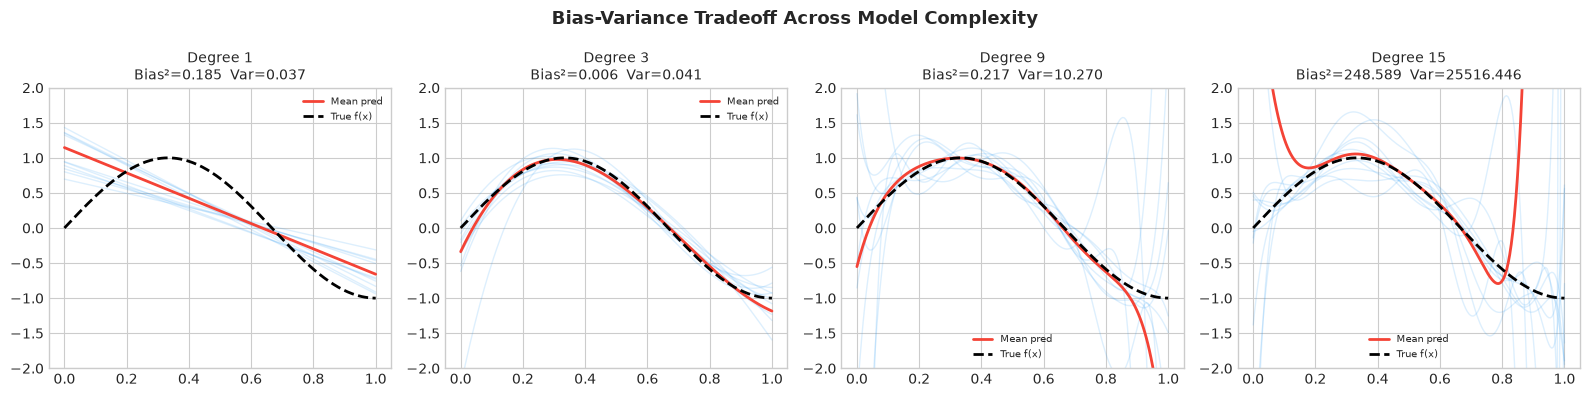

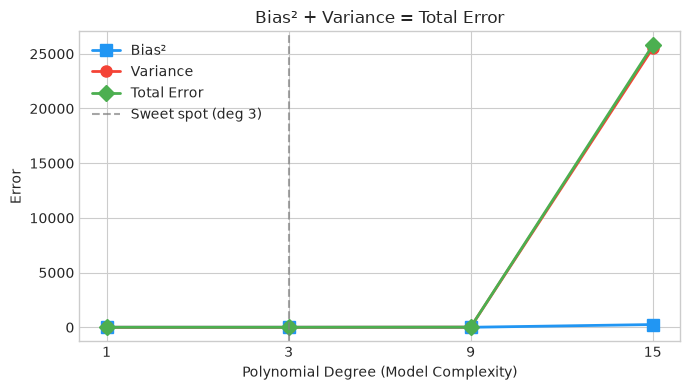


Summary:
  Degree  1: Bias²=0.1846  Var=0.0366  Total=0.2212
  Degree  3: Bias²=0.0059  Var=0.0406  Total=0.0465
  Degree  9: Bias²=0.2171  Var=10.2698  Total=10.4869
  Degree 15: Bias²=248.5885  Var=25516.4459  Total=25765.0344


In [2]:
# ── Bias-Variance Demo: polynomial degree vs. error ──────────────────────────
np.random.seed(42)

def true_function(x):
    return np.sin(1.5 * np.pi * x)

N_TRAIN = 20
N_EXPERIMENTS = 100
x_test = np.linspace(0, 1, 200)

degrees = [1, 3, 9, 15]
bias2_list, var_list, total_list = [], [], []

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, deg in zip(axes, degrees):
    preds = []
    for _ in range(N_EXPERIMENTS):
        x_train = np.sort(np.random.rand(N_TRAIN))
        y_train = true_function(x_train) + np.random.randn(N_TRAIN) * 0.3
        poly = PolynomialFeatures(degree=deg)
        lr   = LinearRegression()
        lr.fit(poly.fit_transform(x_train.reshape(-1,1)), y_train)
        preds.append(lr.predict(poly.transform(x_test.reshape(-1,1))))

    preds = np.array(preds)
    mean_pred = preds.mean(axis=0)
    true_vals = true_function(x_test)
    bias2 = np.mean((mean_pred - true_vals)**2)
    variance = np.mean(preds.var(axis=0))
    bias2_list.append(bias2);  var_list.append(variance)
    total_list.append(bias2 + variance)

    # plot first 10 fits + mean
    for i in range(10):
        ax.plot(x_test, preds[i], alpha=0.15, color=COLORS[0], lw=1)
    ax.plot(x_test, mean_pred, color=COLORS[1], lw=2, label='Mean pred')
    ax.plot(x_test, true_vals, 'k--', lw=2, label='True f(x)')
    ax.set_title(f'Degree {deg}\nBias²={bias2:.3f}  Var={variance:.3f}', fontsize=10)
    ax.set_ylim(-2, 2);  ax.legend(fontsize=7)

plt.suptitle('Bias-Variance Tradeoff Across Model Complexity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/bv_fits.png', dpi=100, bbox_inches='tight')
plt.show()

# ── Bias-Variance vs. complexity curve ───────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(7, 4))
deg_labels = [str(d) for d in degrees]
ax2.plot(deg_labels, bias2_list, 's-', color=COLORS[0], lw=2, ms=8, label='Bias²')
ax2.plot(deg_labels, var_list,   'o-', color=COLORS[1], lw=2, ms=8, label='Variance')
ax2.plot(deg_labels, total_list, 'D-', color=COLORS[2], lw=2, ms=8, label='Total Error')
ax2.axvline(x='3', color='gray', ls='--', alpha=0.7, label='Sweet spot (deg 3)')
ax2.set_xlabel('Polynomial Degree (Model Complexity)');  ax2.set_ylabel('Error')
ax2.set_title('Bias² + Variance = Total Error');  ax2.legend()
plt.tight_layout();  plt.show()

print("\nSummary:")
for d, b, v, t in zip(degrees, bias2_list, var_list, total_list):
    print(f"  Degree {d:2d}: Bias²={b:.4f}  Var={v:.4f}  Total={t:.4f}")

### INTERVIEW QUESTION
**"Explain the bias-variance tradeoff and how it guides model selection."**

**Senior DS Answer:**
> The bias-variance tradeoff describes the fundamental tension in supervised learning. Bias is the error from wrong assumptions — a linear model fit to quadratic data has high bias. Variance is error from sensitivity to training-set fluctuations — a degree-15 polynomial memorizes noise and gives wildly different predictions on new data.
>
> Mathematically, expected MSE = Bias² + Variance + irreducible noise. You can't eliminate all three simultaneously. As you increase model complexity, bias decreases but variance increases. The optimal model sits at the sweet spot where total error is minimized.
>
> Practically: if your model has high train error AND high test error → high bias, try a more complex model. If it has low train error but high test error → high variance, try regularization, more data, or simpler model. This diagnosis drives every modeling decision I make.

---
## 2. Overfitting vs Underfitting

| | Underfitting (High Bias) | Good Fit | Overfitting (High Variance) |
|---|---|---|---|
| Training error | High | Low | Very low |
| Validation error | High | Low | High |
| Gap (val - train) | Small | Small | Large |
| Solution | More complexity, better features | — | Regularize, more data, pruning |

**Learning curves** are the standard diagnostic tool.

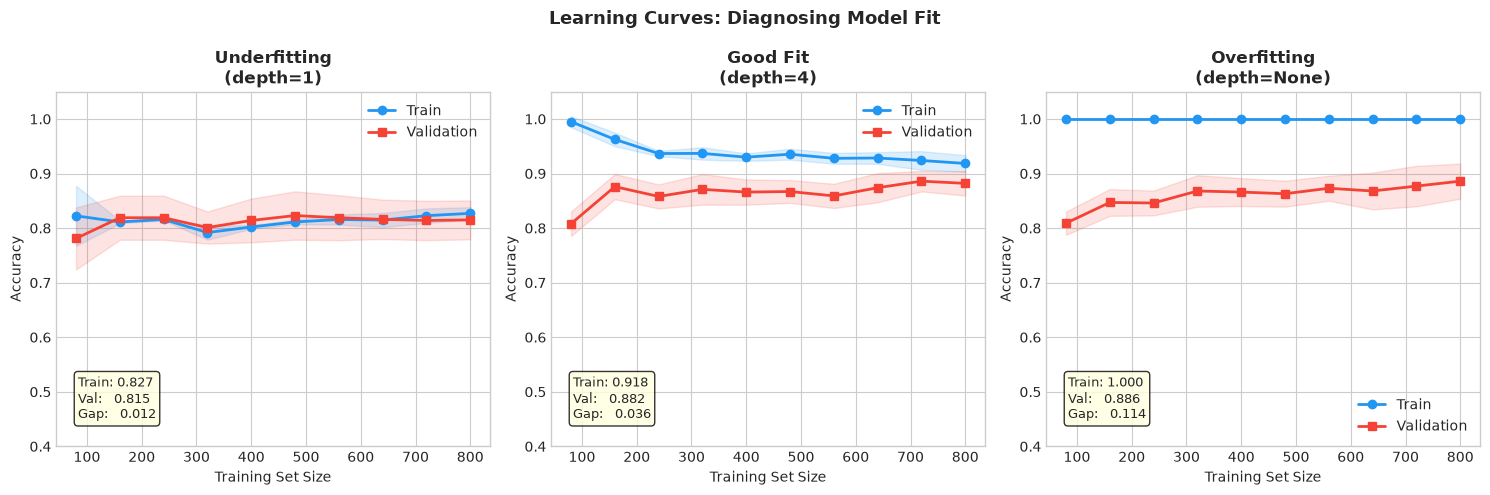

In [3]:
# ── Learning Curves: diagnose over/underfitting ───────────────────────────────
from sklearn.model_selection import learning_curve

X, y = make_classification(n_samples=1000, n_features=20, n_informative=5,
                            n_redundant=5, random_state=42)

models = {
    'Underfitting\n(depth=1)':     DecisionTreeClassifier(max_depth=1, random_state=42),
    'Good Fit\n(depth=4)':         DecisionTreeClassifier(max_depth=4, random_state=42),
    'Overfitting\n(depth=None)':   DecisionTreeClassifier(max_depth=None, random_state=42),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (title, model) in zip(axes, models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy')

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color=COLORS[0], lw=2, label='Train')
    ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std,
                    alpha=0.15, color=COLORS[0])
    ax.plot(train_sizes, val_mean, 's-', color=COLORS[1], lw=2, label='Validation')
    ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std,
                    alpha=0.15, color=COLORS[1])
    ax.set_xlabel('Training Set Size');  ax.set_ylabel('Accuracy')
    ax.set_title(title, fontweight='bold');  ax.legend();  ax.set_ylim(0.4, 1.05)

    final_gap = train_mean[-1] - val_mean[-1]
    ax.text(0.05, 0.08,
            f'Train: {train_mean[-1]:.3f}\nVal:   {val_mean[-1]:.3f}\nGap:   {final_gap:.3f}',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Learning Curves: Diagnosing Model Fit', fontsize=13, fontweight='bold')
plt.tight_layout();  plt.show()

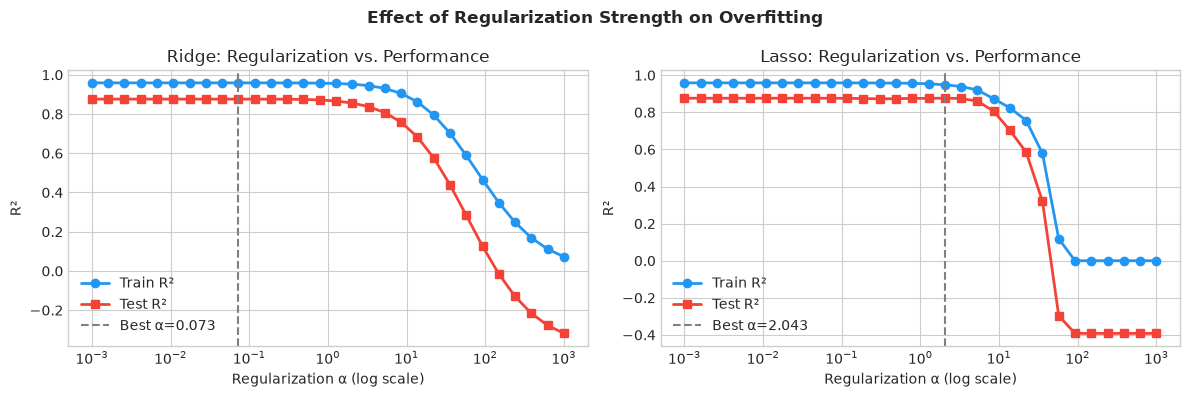

In [4]:
# ── Solutions to overfitting: regularization strength effect ─────────────────
from sklearn.datasets import make_regression

X_reg, y_reg = make_regression(n_samples=50, n_features=20, n_informative=5,
                                noise=30, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr);  X_te_s = scaler.transform(X_te)

alphas = np.logspace(-3, 3, 30)
ridge_train, ridge_test, lasso_train, lasso_test = [], [], [], []

for a in alphas:
    r = Ridge(alpha=a).fit(X_tr_s, y_tr)
    ridge_train.append(r.score(X_tr_s, y_tr));  ridge_test.append(r.score(X_te_s, y_te))
    l = Lasso(alpha=a, max_iter=5000).fit(X_tr_s, y_tr)
    lasso_train.append(l.score(X_tr_s, y_tr));  lasso_test.append(l.score(X_te_s, y_te))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for ax, tr, te, name in [(ax1, ridge_train, ridge_test, 'Ridge'),
                          (ax2, lasso_train, lasso_test, 'Lasso')]:
    ax.semilogx(alphas, tr, 'o-', color=COLORS[0], lw=2, label='Train R²')
    ax.semilogx(alphas, te, 's-', color=COLORS[1], lw=2, label='Test R²')
    ax.axvline(alphas[np.argmax(te)], color='gray', ls='--', label=f'Best α={alphas[np.argmax(te)]:.3f}')
    ax.set_xlabel('Regularization α (log scale)');  ax.set_ylabel('R²')
    ax.set_title(f'{name}: Regularization vs. Performance');  ax.legend()
plt.suptitle('Effect of Regularization Strength on Overfitting', fontsize=12, fontweight='bold')
plt.tight_layout();  plt.show()

### INTERVIEW QUESTION
**"How do you detect and fix overfitting?"**

**Senior DS Answer:**
> I diagnose overfitting with learning curves: plot train vs. validation error as a function of training set size. Overfitting shows as a large gap — low train error, high val error. If adding data closes the gap, you need more data. If not, the model is too complex.
>
> Fixes, in order of preference: (1) Regularization — L2 for neural nets/regression, L1 if you suspect only a few features matter; (2) Simpler model — prune trees, reduce layers/units; (3) More training data or data augmentation; (4) Dropout for neural nets; (5) Early stopping — stop when val loss starts rising; (6) Ensemble methods — averaging predictions reduces variance.
>
> The key insight: overfitting is a variance problem. Every solution reduces sensitivity to the specific training set.

---
## 3. Regularization Deep Dive: L1, L2, ElasticNet

### Mathematical Differences

| | L2 (Ridge) | L1 (Lasso) | ElasticNet |
|---|---|---|---|
| Penalty | $\lambda \sum w_i^2$ | $\lambda \sum |w_i|$ | $\lambda_1 \sum |w_i| + \lambda_2 \sum w_i^2$ |
| Geometry | Circular constraint | Diamond constraint | Combination |
| Sparse solution? | No — shrinks toward 0 | Yes — exactly 0 | Yes — some exactly 0 |
| Correlated features | Keeps all, shares weight | Picks one arbitrarily | Groups and selects |
| Best when | Many small useful features | Many irrelevant features | Groups of correlated features |

**Why L1 produces sparsity:** The diamond constraint has corners on the axes. Optimization finds the constraint boundary tangent to the loss contour. Corners are far more likely to be tangent points than the smooth circle of L2, and corners lie on an axis where other weights are exactly zero.

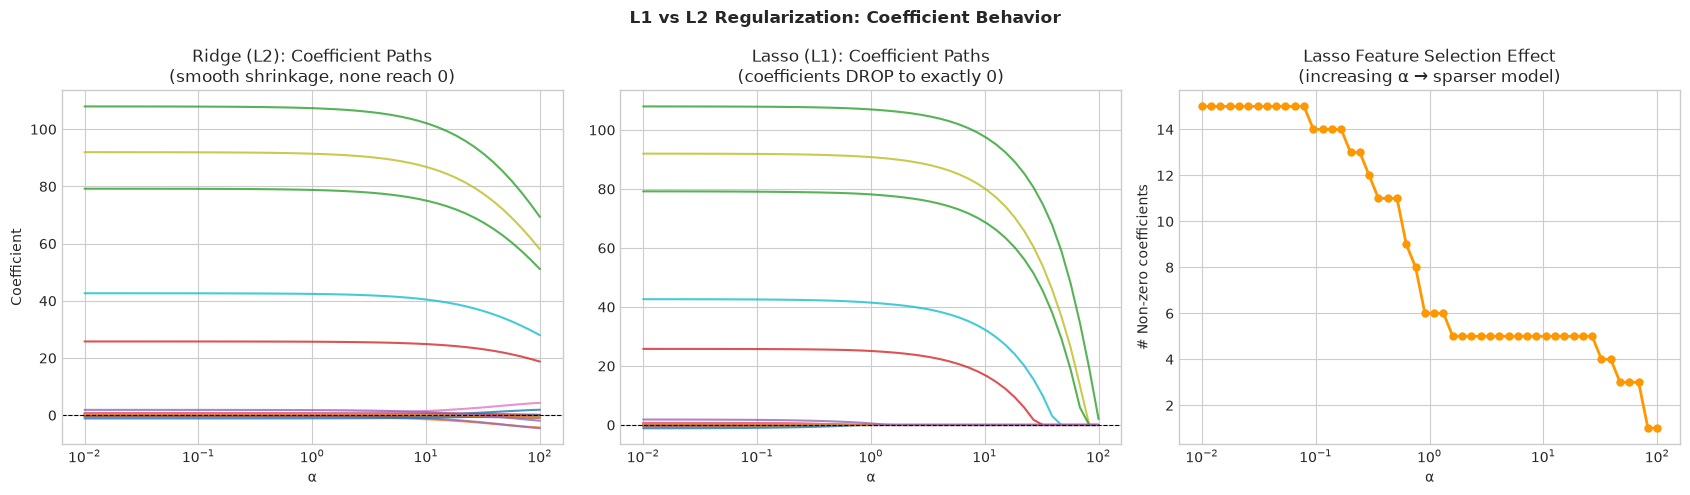

In [5]:
# ── Coefficient paths: L1 vs L2 ──────────────────────────────────────────────
X_r, y_r = make_regression(n_samples=200, n_features=15, n_informative=5,
                             noise=20, random_state=42)
scaler2 = StandardScaler()
X_rs = scaler2.fit_transform(X_r)

alphas_path = np.logspace(-2, 2, 50)

ridge_coefs = np.array([Ridge(alpha=a).fit(X_rs, y_r).coef_ for a in alphas_path])
lasso_coefs = np.array([Lasso(alpha=a, max_iter=5000).fit(X_rs, y_r).coef_
                         for a in alphas_path])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5))

# Ridge paths
for i in range(15):
    ax1.semilogx(alphas_path, ridge_coefs[:, i], lw=1.5, alpha=0.8)
ax1.axhline(0, color='k', ls='--', lw=0.8);  ax1.set_xlabel('α');  ax1.set_ylabel('Coefficient')
ax1.set_title('Ridge (L2): Coefficient Paths\n(smooth shrinkage, none reach 0)')

# Lasso paths
for i in range(15):
    ax2.semilogx(alphas_path, lasso_coefs[:, i], lw=1.5, alpha=0.8)
ax2.axhline(0, color='k', ls='--', lw=0.8);  ax2.set_xlabel('α')
ax2.set_title('Lasso (L1): Coefficient Paths\n(coefficients DROP to exactly 0)')

# Non-zero count
n_nonzero = (np.abs(lasso_coefs) > 1e-6).sum(axis=1)
ax3.semilogx(alphas_path, n_nonzero, 'o-', color=COLORS[3], lw=2, ms=5)
ax3.set_xlabel('α');  ax3.set_ylabel('# Non-zero coefficients')
ax3.set_title('Lasso Feature Selection Effect\n(increasing α → sparser model)')

plt.suptitle('L1 vs L2 Regularization: Coefficient Behavior', fontsize=12, fontweight='bold')
plt.tight_layout();  plt.show()

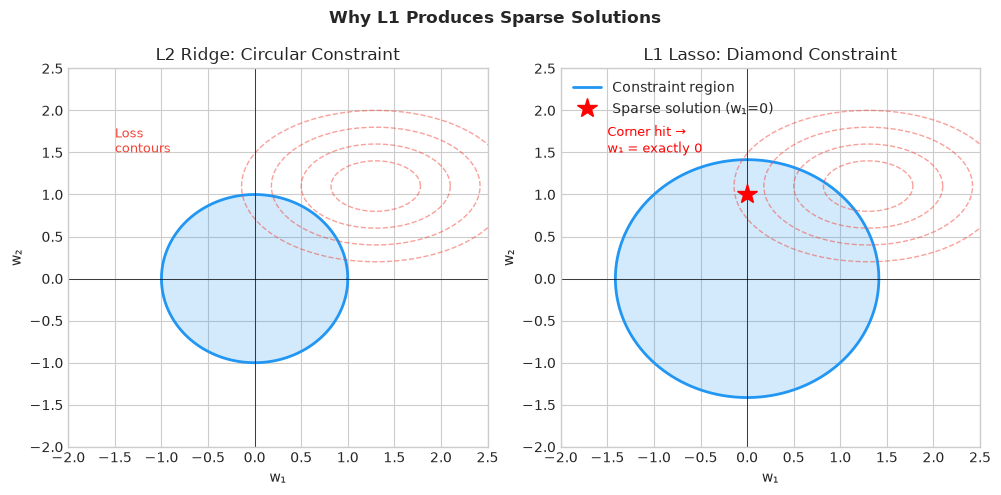

In [6]:
# ── Geometric intuition: L1 vs L2 constraint regions ────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

theta = np.linspace(0, 2*np.pi, 300)

for ax, title, shape_x, shape_y in [
    (ax1, 'L2 Ridge: Circular Constraint',
     np.cos(theta), np.sin(theta)),
    (ax2, 'L1 Lasso: Diamond Constraint',
     np.cos(theta + np.pi/4) / np.cos(np.pi/4),
     np.sin(theta + np.pi/4) / np.cos(np.pi/4))]:

    ax.fill(shape_x, shape_y, alpha=0.2, color=COLORS[0])
    ax.plot(shape_x, shape_y, color=COLORS[0], lw=2, label='Constraint region')

    # Loss contours (ellipses centered off-axis)
    for r in [0.6, 1.0, 1.4, 1.8]:
        ellipse_x = 1.3 + r * np.cos(theta) * 0.8
        ellipse_y = 1.1 + r * np.sin(theta) * 0.5
        ax.plot(ellipse_x, ellipse_y, '--', color=COLORS[1], alpha=0.5, lw=1)

    ax.set_xlim(-2, 2.5);  ax.set_ylim(-2, 2.5)
    ax.axhline(0, color='k', lw=0.5);  ax.axvline(0, color='k', lw=0.5)
    ax.set_xlabel('w₁');  ax.set_ylabel('w₂');  ax.set_title(title)

# Mark where L1 tangent is likely (a corner: w1=0)
ax2.plot(0, 1, 'r*', ms=15, label='Sparse solution (w₁=0)')
ax2.legend()
ax1.text(-1.5, 1.5, 'Loss\ncontours', color=COLORS[1], fontsize=9)
ax2.text(-1.5, 1.5, 'Corner hit →\nw₁ = exactly 0', color='red', fontsize=9)

plt.suptitle('Why L1 Produces Sparse Solutions', fontsize=12, fontweight='bold')
plt.tight_layout();  plt.show()

### INTERVIEW QUESTION
**"Why does L1 regularization produce sparse solutions but L2 does not?"**

**Senior DS Answer:**
> Geometrically, regularization adds a constraint to the optimization: the solution must lie within a feasible region. For L2, that region is a hypersphere — smooth, no corners. For L1, it's a hypercube rotated 45° — a diamond in 2D — with corners sitting exactly on the coordinate axes.
>
> The solution is where the loss function's contours first touch the constraint boundary. A smooth sphere can be tangent anywhere, so coefficients shrink uniformly toward zero but rarely reach it exactly. The diamond has sharp corners on the axes, and due to the convexity of typical loss functions, the optimum is far more likely to lie at a corner — where some weights are exactly zero.
>
> Mathematically: L1's subdifferential at zero has a range, meaning the gradient condition $0 \in \partial L$ can be satisfied with the coefficient exactly at zero whenever the unregularized gradient is smaller than $\lambda$. L2's derivative at zero is just 0, so it only pushes weights toward — never exactly to — zero.
>
> Practical rule: Use L1 (Lasso) when you suspect many features are irrelevant. Use L2 (Ridge) when all features likely contribute. Use ElasticNet when features are grouped/correlated.

---
## 4. Cross-Validation Strategies

| Strategy | When to use | Pros | Cons |
|---|---|---|---|
| K-Fold | Standard | Balanced, efficient | Not stratified by default |
| Stratified K-Fold | Classification / imbalanced | Preserves class ratios | N/A for regression |
| TimeSeriesSplit | Time-ordered data | No future leakage | Less data for early folds |
| Leave-One-Out | Very small datasets (<50) | Maximum training data | Very slow, high variance |
| Nested CV | Hyperparameter tuning | Unbiased generalization estimate | Computationally expensive |

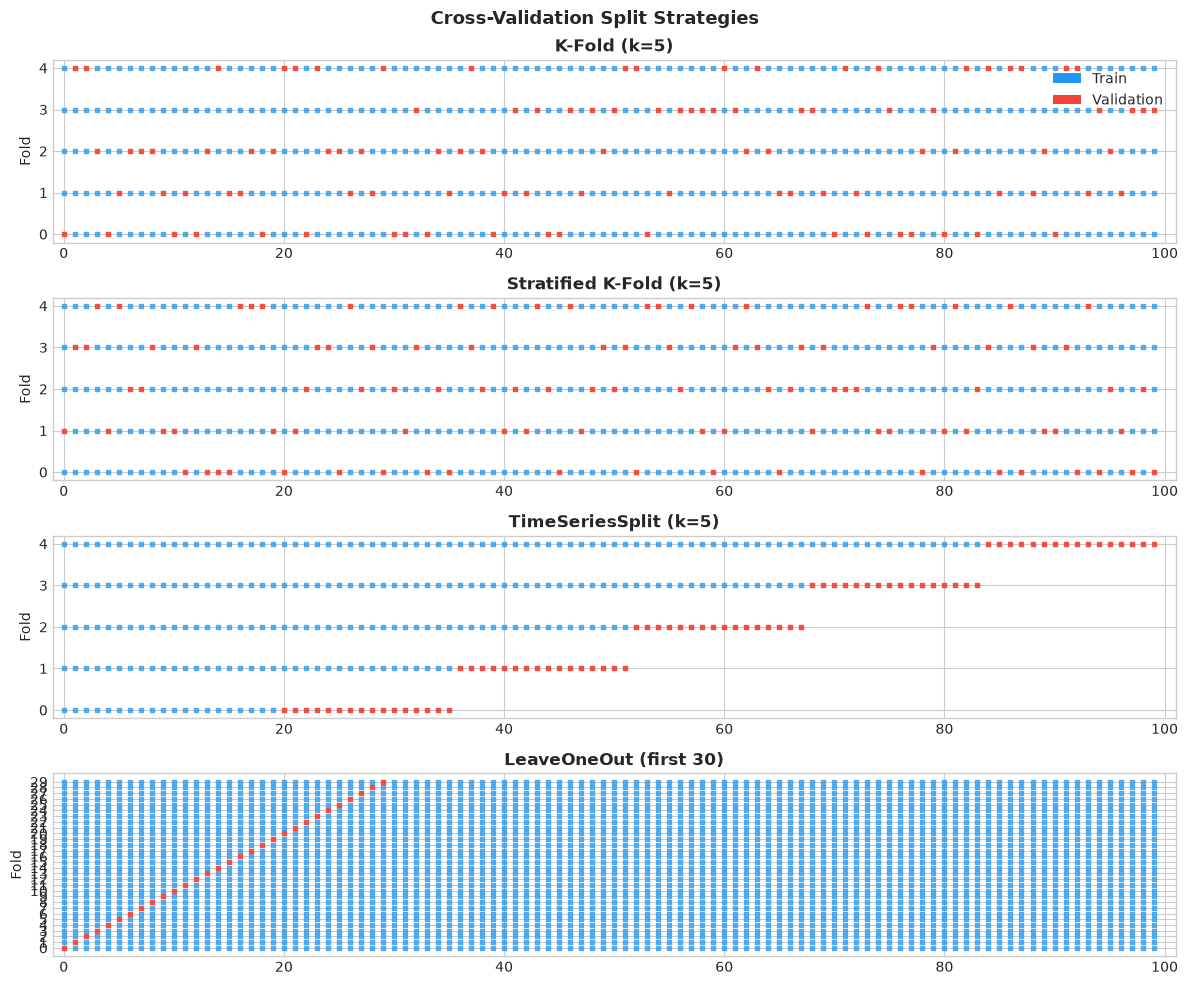

In [7]:
# ── Visualize CV split strategies ────────────────────────────────────────────
n_samples = 100
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

cv_strategies = [
    ('K-Fold (k=5)',          KFold(n_splits=5, shuffle=True, random_state=42)),
    ('Stratified K-Fold (k=5)',StratifiedKFold(n_splits=5, shuffle=True, random_state=42)),
    ('TimeSeriesSplit (k=5)',  TimeSeriesSplit(n_splits=5)),
    ('LeaveOneOut (first 30)', LeaveOneOut()),
]

X_cv = np.arange(n_samples).reshape(-1, 1)
y_cv = np.array([0]*50 + [1]*50)  # balanced classes

for ax, (title, cv) in zip(axes, cv_strategies):
    splits = list(cv.split(X_cv, y_cv))
    if isinstance(cv, LeaveOneOut):
        splits = splits[:30]  # only show first 30

    for fold_i, (train_idx, val_idx) in enumerate(splits):
        ax.scatter(train_idx, np.full_like(train_idx, fold_i), c=COLORS[0],
                   marker='s', s=10, alpha=0.7)
        ax.scatter(val_idx, np.full_like(val_idx, fold_i), c=COLORS[1],
                   marker='s', s=10, alpha=0.9)

    ax.set_ylabel('Fold');  ax.set_title(title, fontweight='bold')
    ax.set_xlim(-1, n_samples+1);  ax.set_yticks(range(len(splits)))

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COLORS[0], label='Train'),
                   Patch(facecolor=COLORS[1], label='Validation')]
axes[0].legend(handles=legend_elements, loc='upper right')

plt.suptitle('Cross-Validation Split Strategies', fontsize=13, fontweight='bold')
plt.tight_layout();  plt.show()

In [8]:
# ── TimeSeriesSplit: why order matters ────────────────────────────────────────
np.random.seed(42)
n = 200
t = np.arange(n)
# Synthetic time series: trend + seasonality + noise
y_ts = 0.05*t + 5*np.sin(2*np.pi*t/52) + np.random.randn(n)*2

X_ts = np.column_stack([t, np.sin(2*np.pi*t/52), np.cos(2*np.pi*t/52)])

tscv = TimeSeriesSplit(n_splits=5)
kfcv = KFold(n_splits=5, shuffle=True, random_state=42)

ts_scores, kf_scores = [], []
for (tr, te) in tscv.split(X_ts):
    m = LinearRegression().fit(X_ts[tr], y_ts[tr])
    ts_scores.append(r2_score(y_ts[te], m.predict(X_ts[te])))

for (tr, te) in kfcv.split(X_ts):
    m = LinearRegression().fit(X_ts[tr], y_ts[tr])
    kf_scores.append(r2_score(y_ts[te], m.predict(X_ts[te])))

print("Time series data — Cross-validation R² scores:")
print(f"  TimeSeriesSplit: {np.mean(ts_scores):.4f} ± {np.std(ts_scores):.4f}  (correct)")
print(f"  KFold (shuffled): {np.mean(kf_scores):.4f} ± {np.std(kf_scores):.4f}  (WRONG — leaks future into past!)")
print()
print("KFold is optimistic because it trains on future data to predict the past.")
print("Always use TimeSeriesSplit for temporal data.")

Time series data — Cross-validation R² scores:
  TimeSeriesSplit: 0.7540 ± 0.0733  (correct)
  KFold (shuffled): 0.8465 ± 0.0399  (WRONG — leaks future into past!)

KFold is optimistic because it trains on future data to predict the past.
Always use TimeSeriesSplit for temporal data.


### INTERVIEW QUESTION
**"When would you use Stratified K-Fold vs TimeSeriesSplit, and what is data leakage through CV?"**

**Senior DS Answer:**
> Use **Stratified K-Fold** for any classification problem, especially with class imbalance. It ensures each fold has the same class proportions as the full dataset — without it, a fold might have no minority class samples, making evaluation meaningless.
>
> Use **TimeSeriesSplit** whenever observations are ordered in time and future values could influence predictions. Standard K-Fold shuffles the data, so a model can be trained on week 52 to predict week 1 — that's future leakage masking as good performance.
>
> **Data leakage through CV** is subtle: if you fit a preprocessing step (scaler, imputer, feature selector) on the entire dataset before CV, validation-fold statistics have "seen" training data. The fix is to put preprocessing inside a Pipeline — sklearn's cross_val_score then fits preprocessing only on training folds.

---
## 5. Data Leakage

**Definition:** Information from outside the legitimate training distribution enters the model, causing it to appear better than it will perform in production.

### 5 Real Examples

| # | Type | Example | How to detect |
|---|---|---|---|
| 1 | **Target leakage** | "days_in_hospital" predicting readmission — only known after readmission | Check feature timing against target |
| 2 | **Preprocessing leakage** | Scaling with full-dataset statistics before CV | Use Pipelines |
| 3 | **Temporal leakage** | Using data from the future to predict the past | Strict time-based splits |
| 4 | **Train/test contamination** | Deduplicating after splitting — same patient in both sets | Split first, then clean |
| 5 | **Label leakage** | Feature is a proxy for the target (e.g., "diagnosis_code" predicting "disease") | Domain review of features |

In [9]:
# ── Data leakage demonstration: scaling before vs. after split ───────────────
np.random.seed(42)
X_leak, y_leak = make_classification(n_samples=500, n_features=20,
                                      n_informative=5, random_state=42)

from sklearn.model_selection import cross_val_score

# WRONG: scale entire dataset, then cross-validate
scaler_bad = StandardScaler()
X_scaled_bad = scaler_bad.fit_transform(X_leak)   # LEAKS val stats into training!
scores_bad = cross_val_score(LogisticRegression(max_iter=1000),
                              X_scaled_bad, y_leak, cv=5, scoring='roc_auc')

# CORRECT: Pipeline ensures scaling happens only on training fold
from sklearn.pipeline import Pipeline
pipeline_good = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])
scores_good = cross_val_score(pipeline_good, X_leak, y_leak, cv=5, scoring='roc_auc')

print("Scaling Leakage Demonstration:")
print(f"  WRONG  (scale then CV): AUC = {scores_bad.mean():.4f} ± {scores_bad.std():.4f}")
print(f"  CORRECT (Pipeline CV):  AUC = {scores_good.mean():.4f} ± {scores_good.std():.4f}")
print()

# ── Target leakage demonstration ─────────────────────────────────────────────
np.random.seed(42)
n = 1000
# True signal: age + income predict default
age    = np.random.randint(20, 70, n)
income = np.random.normal(50000, 20000, n)
default_prob = 1 / (1 + np.exp(-(0.03*(age-45) - income/50000 + 0.5)))
default = (np.random.rand(n) < default_prob).astype(int)

# Leaked feature: "days_past_due" — ONLY exists after default
days_past_due = default * np.random.randint(1, 90, n) + (1-default)*0

df_leak = pd.DataFrame({'age': age, 'income': income,
                        'days_past_due': days_past_due, 'default': default})

# With leaked feature
X_with_leak = df_leak[['age', 'income', 'days_past_due']]
X_without    = df_leak[['age', 'income']]

from sklearn.ensemble import RandomForestClassifier
pipe_with    = Pipeline([('s', StandardScaler()), ('m', RandomForestClassifier(n_estimators=50, random_state=42))])
pipe_without = Pipeline([('s', StandardScaler()), ('m', RandomForestClassifier(n_estimators=50, random_state=42))])

auc_with    = cross_val_score(pipe_with,    X_with_leak, default, cv=5, scoring='roc_auc').mean()
auc_without = cross_val_score(pipe_without, X_without,   default, cv=5, scoring='roc_auc').mean()

print("Target Leakage Demonstration:")
print(f"  WITH leaked feature (days_past_due): AUC = {auc_with:.4f}  ← impossibly good!")
print(f"  WITHOUT leaked feature:              AUC = {auc_without:.4f}  ← realistic")
print()
print("'days_past_due' only exists AFTER the default event — using it is cheating.")

Scaling Leakage Demonstration:
  WRONG  (scale then CV): AUC = 0.8999 ± 0.0265
  CORRECT (Pipeline CV):  AUC = 0.8999 ± 0.0264



Target Leakage Demonstration:
  WITH leaked feature (days_past_due): AUC = 1.0000  ← impossibly good!
  WITHOUT leaked feature:              AUC = 0.5909  ← realistic

'days_past_due' only exists AFTER the default event — using it is cheating.


### INTERVIEW QUESTION
**"What is data leakage and how do you prevent it?"**

**Senior DS Answer:**
> Data leakage is when information that wouldn't be available at prediction time enters your training process, making the model appear far better than it truly is. It's one of the leading causes of models that look great in development but fail in production.
>
> The five forms I watch for: **target leakage** (a feature is downstream of the target), **preprocessing leakage** (fit your scaler on the full dataset), **temporal leakage** (train on the future, predict the past), **train-test contamination** (duplicates or related samples split across train/test), and **label leakage** (a feature is essentially the target in disguise).
>
> Prevention: (1) Always split data FIRST, then do any preprocessing. (2) Use sklearn Pipelines — they enforce that transformers are fit only on training data during CV. (3) For time series, use time-based splits, never shuffle. (4) Do a feature audit — for each feature, ask "would I have this value at the moment I need to make the prediction?" (5) Be suspicious of suspiciously high AUC — real business problems rarely have AUC > 0.95.

---
## 6. Feature Selection Methods

Three families:

| Family | Method | Pros | Cons |
|---|---|---|---|
| **Filter** | Correlation, chi², mutual info | Fast, model-agnostic | Ignores feature interactions |
| **Wrapper** | RFE, forward/backward selection | Finds best subset for specific model | Slow, risk of overfitting |
| **Embedded** | Lasso coefficients, tree importance | Efficient, considers interactions | Model-specific |

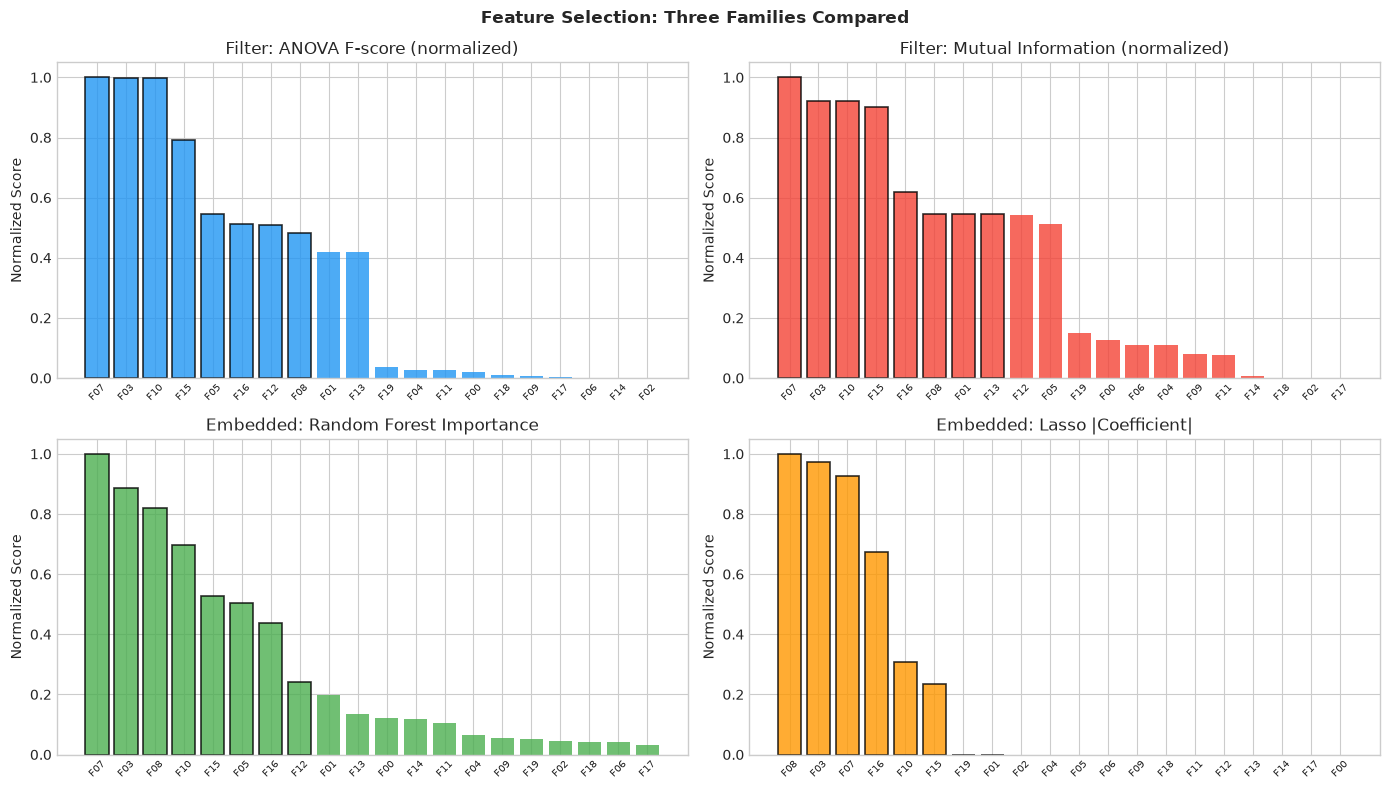

Top-8 features agreement (Jaccard similarity):
  F-test vs Mutual Info:   0.60
  F-test vs RF Importance: 1.00
  F-test vs RFE:           0.78


In [10]:
# ── All three feature selection families ─────────────────────────────────────
from sklearn.datasets import make_classification
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)
X_fs, y_fs = make_classification(n_samples=500, n_features=20,
                                  n_informative=8, n_redundant=4,
                                  n_repeated=2, n_clusters_per_class=1,
                                  random_state=42)
feat_names = [f'F{i:02d}' for i in range(20)]

# ── 1. Filter: ANOVA F-test ──
selector_f = SelectKBest(f_classif, k=8).fit(X_fs, y_fs)
f_scores   = selector_f.scores_

# ── 2. Filter: Mutual Information ──
mi_scores = mutual_info_classif(X_fs, y_fs, random_state=42)

# ── 3. Wrapper: RFE with Logistic Regression ──
rfe = RFE(LogisticRegression(max_iter=1000, C=0.1), n_features_to_select=8)
rfe.fit(StandardScaler().fit_transform(X_fs), y_fs)
rfe_ranking = rfe.ranking_  # 1 = selected

# ── 4. Embedded: Random Forest importance ──
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_fs, y_fs)
rf_importance = rf.feature_importances_

# ── 5. Embedded: Lasso ──
lasso_fs = Lasso(alpha=0.05).fit(StandardScaler().fit_transform(X_fs), y_fs)
lasso_coef = np.abs(lasso_fs.coef_)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, scores, title, color in [
    (axes[0,0], f_scores/f_scores.max(),          'Filter: ANOVA F-score (normalized)', COLORS[0]),
    (axes[0,1], mi_scores/mi_scores.max(),         'Filter: Mutual Information (normalized)', COLORS[1]),
    (axes[1,0], rf_importance/rf_importance.max(), 'Embedded: Random Forest Importance', COLORS[2]),
    (axes[1,1], lasso_coef/lasso_coef.max() if lasso_coef.max()>0 else lasso_coef,
                                                    'Embedded: Lasso |Coefficient|', COLORS[3]),
]:
    order = np.argsort(scores)[::-1]
    bars = ax.bar(range(20), scores[order], color=color, alpha=0.8)
    ax.set_xticks(range(20));  ax.set_xticklabels([feat_names[i] for i in order], rotation=45, fontsize=7)
    ax.set_title(title);  ax.set_ylabel('Normalized Score')
    # Highlight top 8
    for b in bars[:8]:
        b.set_edgecolor('black');  b.set_linewidth(1.2)

plt.suptitle('Feature Selection: Three Families Compared', fontsize=12, fontweight='bold')
plt.tight_layout();  plt.show()

# Agreement between methods
top8_f    = set(np.argsort(f_scores)[-8:])
top8_mi   = set(np.argsort(mi_scores)[-8:])
top8_rf   = set(np.argsort(rf_importance)[-8:])
top8_rfe  = set(np.where(rfe_ranking == 1)[0])
top8_las  = set(np.argsort(lasso_coef)[-8:])
print("Top-8 features agreement (Jaccard similarity):")
print(f"  F-test vs Mutual Info:   {len(top8_f & top8_mi)/len(top8_f | top8_mi):.2f}")
print(f"  F-test vs RF Importance: {len(top8_f & top8_rf)/len(top8_f | top8_rf):.2f}")
print(f"  F-test vs RFE:           {len(top8_f & top8_rfe)/len(top8_f | top8_rfe):.2f}")

### INTERVIEW QUESTION
**"How do you select features for a model, and which method do you prefer?"**

**Senior DS Answer:**
> I use a layered approach. First, domain knowledge — if a feature can't logically cause the outcome, remove it regardless of correlation. Next, a quick filter pass using mutual information or ANOVA F-test to drop clearly uninformative features, which speeds up everything downstream.
>
> For the final model, I prefer embedded methods — specifically random forest importance for tree models, and Lasso for linear models. They do feature selection as part of fitting, so there's no double-dipping on the validation set.
>
> I avoid pure wrapper methods like RFE for high-dimensional data because they're O(p²) in the number of features and prone to overfitting the feature selection itself. If I must use RFE, it goes inside nested cross-validation.
>
> Two traps I watch for: (1) never select features on the full dataset before CV — that's leakage; always wrap feature selection in the pipeline. (2) High correlation between a feature and target doesn't mean causation — always sanity-check what the feature actually represents.

---
## 7. Class Imbalance

When class distribution is skewed (e.g., 1% fraud), a model predicting "majority class always" gets 99% accuracy but 0% recall on what matters.

### Strategies

| Strategy | How | When |
|---|---|---|
| `class_weight='balanced'` | Upweights minority loss | Always try first — zero cost |
| SMOTE | Synthesize minority samples | Moderate imbalance (5-20%) |
| Random undersampling | Remove majority samples | When majority >> minority |
| Threshold tuning | Move decision boundary | When FP/FN costs differ |
| Ensemble (BalancedRF) | Balanced bootstrap per tree | Tree models, severe imbalance |
| **Evaluation** | Use Precision-Recall, F1, AUC-PR | Never report accuracy alone |

In [11]:
# ── Class imbalance: strategies comparison ───────────────────────────────────
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report, average_precision_score

np.random.seed(42)
X_imb, y_imb = make_classification(
    n_samples=10000, n_features=20, n_informative=8,
    weights=[0.95, 0.05],   # 95% class-0, 5% class-1
    flip_y=0, random_state=42)

X_tr, X_te, y_tr, y_te = train_test_split(X_imb, y_imb, test_size=0.3,
                                            stratify=y_imb, random_state=42)
scaler_imb = StandardScaler()
X_tr_s = scaler_imb.fit_transform(X_tr);  X_te_s = scaler_imb.transform(X_te)

print(f"Class distribution — Train: {dict(zip(*np.unique(y_tr, return_counts=True)))}")
print(f"                      Test:  {dict(zip(*np.unique(y_te, return_counts=True)))}")
print()

results = {}

# 1. Baseline (no handling)
lr_base = LogisticRegression(max_iter=1000).fit(X_tr_s, y_tr)
y_pred_base = lr_base.predict(X_te_s)
y_prob_base = lr_base.predict_proba(X_te_s)[:,1]
results['Baseline'] = {'y_pred': y_pred_base, 'y_prob': y_prob_base}

# 2. class_weight='balanced'
lr_cw = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X_tr_s, y_tr)
y_pred_cw = lr_cw.predict(X_te_s)
y_prob_cw = lr_cw.predict_proba(X_te_s)[:,1]
results['class_weight=balanced'] = {'y_pred': y_pred_cw, 'y_prob': y_prob_cw}

# 3. Threshold tuning (using class_weight model, lower threshold)
threshold = 0.3
y_pred_thresh = (y_prob_cw >= threshold).astype(int)
results[f'Threshold={threshold}'] = {'y_pred': y_pred_thresh, 'y_prob': y_prob_cw}

# 4. SMOTE
try:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(random_state=42)
    X_sm, y_sm = sm.fit_resample(X_tr_s, y_tr)
    lr_smote = LogisticRegression(max_iter=1000).fit(X_sm, y_sm)
    y_pred_smote = lr_smote.predict(X_te_s)
    y_prob_smote = lr_smote.predict_proba(X_te_s)[:,1]
    results['SMOTE'] = {'y_pred': y_pred_smote, 'y_prob': y_prob_smote}
    smote_available = True
except ImportError:
    print("Note: imbalanced-learn not installed; skipping SMOTE")
    smote_available = False

# ── Print comparison ──────────────────────────────────────────────────────────
print(f"{'Method':<25} {'Accuracy':>8} {'Precision':>9} {'Recall':>7} {'F1':>6} {'AUC-PR':>7}")
print("-" * 65)
for name, r in results.items():
    acc  = accuracy_score(y_te, r['y_pred'])
    prec = precision_score(y_te, r['y_pred'], zero_division=0)
    rec  = recall_score(y_te, r['y_pred'])
    f1   = f1_score(y_te, r['y_pred'])
    ap   = average_precision_score(y_te, r['y_prob'])
    print(f"{name:<25} {acc:>8.4f} {prec:>9.4f} {rec:>7.4f} {f1:>6.4f} {ap:>7.4f}")

Class distribution — Train: {np.int64(0): np.int64(6650), np.int64(1): np.int64(350)}
                      Test:  {np.int64(0): np.int64(2850), np.int64(1): np.int64(150)}

Method                    Accuracy Precision  Recall     F1  AUC-PR
-----------------------------------------------------------------
Baseline                    0.9530    0.9091  0.0667 0.1242  0.3154
class_weight=balanced       0.7080    0.1163  0.7333 0.2007  0.1672


Threshold=0.3               0.4957    0.0867  0.9533 0.1590  0.1672
SMOTE                       0.7123    0.1187  0.7400 0.2046  0.1720


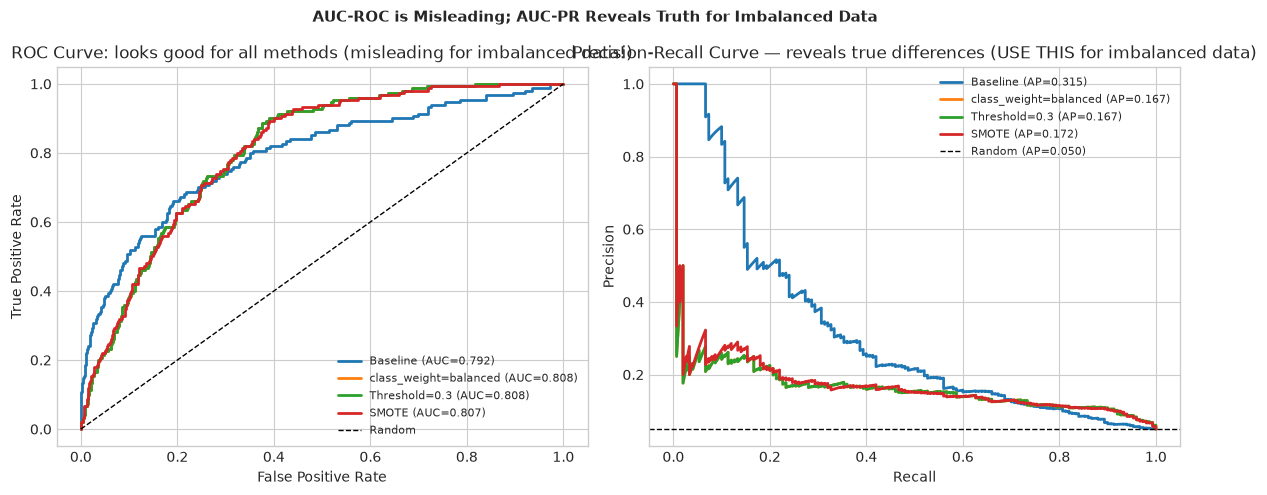

Key insight: ROC curves look similar across all methods.
PR curves show that class_weight='balanced' significantly improves minority-class detection.


In [12]:
# ── Precision-Recall vs ROC curve for imbalanced data ────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ROC curves
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_te, r['y_prob'])
    auc_val = roc_auc_score(y_te, r['y_prob'])
    ax1.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc_val:.3f})')
ax1.plot([0,1],[0,1],'k--', lw=1, label='Random')
ax1.set_xlabel('False Positive Rate');  ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve: looks good for all methods (misleading for imbalanced data!)')
ax1.legend(fontsize=8)

# PR curves
for name, r in results.items():
    prec_c, rec_c, _ = precision_recall_curve(y_te, r['y_prob'])
    ap = average_precision_score(y_te, r['y_prob'])
    ax2.plot(rec_c, prec_c, lw=2, label=f'{name} (AP={ap:.3f})')
baseline_ap = y_te.mean()
ax2.axhline(baseline_ap, color='k', ls='--', lw=1, label=f'Random (AP={baseline_ap:.3f})')
ax2.set_xlabel('Recall');  ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve — reveals true differences (USE THIS for imbalanced data)')
ax2.legend(fontsize=8)

plt.suptitle('AUC-ROC is Misleading; AUC-PR Reveals Truth for Imbalanced Data',
             fontsize=11, fontweight='bold')
plt.tight_layout();  plt.show()

print("Key insight: ROC curves look similar across all methods.")
print("PR curves show that class_weight='balanced' significantly improves minority-class detection.")

### INTERVIEW QUESTION
**"You have a fraud detection dataset where 0.1% are fraudulent. What do you do?"**

**Senior DS Answer:**
> First, I'd resist the urge to just SMOTE everything. My process: (1) **Establish the business objective** — what's the cost of a missed fraud vs. a false positive? This drives everything. (2) **Never use accuracy** — a model saying "not fraud" always gets 99.9% accuracy. Use AUC-PR, F1 on minority class, and business metrics ($ caught/$ lost). (3) Start with `class_weight='balanced'` on any sklearn model — it's free and often solves the problem. (4) Tune the **decision threshold** — instead of defaulting to 0.5, find the threshold that optimizes the business cost function. (5) If still insufficient, try SMOTE but only on training data, never leaking into validation. (6) Consider tree-based ensemble methods which handle imbalance better than linear models. The biggest trap is optimizing for the wrong metric — I've seen teams celebrate 99.8% accuracy on fraud that catches zero fraudulent transactions.

---
## 8. Evaluation Metrics Mastery

### Classification Metrics

| Metric | Formula | Use when |
|---|---|---|
| Accuracy | (TP+TN)/(total) | Balanced classes, equal costs |
| Precision | TP/(TP+FP) | FP is costly (spam filter) |
| Recall | TP/(TP+FN) | FN is costly (cancer detection) |
| F1 | 2·P·R/(P+R) | Need balance of P and R |
| AUC-ROC | Area under ROC | Comparing models regardless of threshold |
| AUC-PR | Area under PR curve | Imbalanced data |

### Regression Metrics

| Metric | Formula | Sensitive to | Use when |
|---|---|---|---|
| MSE/RMSE | mean((y-ŷ)²) | Outliers | Outliers important |
| MAE | mean(\|y-ŷ\|) | Robust | Outliers less important |
| MAPE | mean(\|y-ŷ\|/\|y\|) | Small y values | Relative error, no zeros |
| R² | 1 - SS_res/SS_tot | Scale | Proportion variance explained |

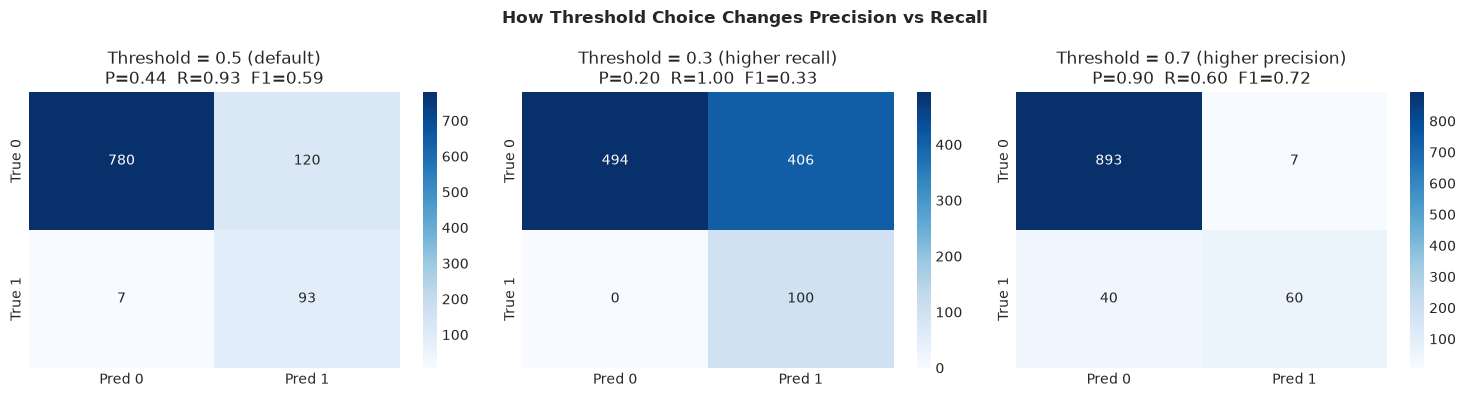

In [13]:
# ── Confusion matrix anatomy ─────────────────────────────────────────────────
y_true_demo = np.array([1]*100 + [0]*900)
# Simulate model: decent on majority, weaker on minority
np.random.seed(42)
y_prob_demo = np.where(y_true_demo==1,
                        np.random.beta(5, 2, 1000),    # minority: higher scores
                        np.random.beta(2, 5, 1000))     # majority: lower scores

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, thresh, title in [(axes[0], 0.5, 'Threshold = 0.5 (default)'),
                           (axes[1], 0.3, 'Threshold = 0.3 (higher recall)'),
                           (axes[2], 0.7, 'Threshold = 0.7 (higher precision)')]:
    y_pred_demo = (y_prob_demo >= thresh).astype(int)
    cm = confusion_matrix(y_true_demo, y_pred_demo)
    p  = precision_score(y_true_demo, y_pred_demo, zero_division=0)
    r  = recall_score(y_true_demo, y_pred_demo)
    f1_v = f1_score(y_true_demo, y_pred_demo)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
    ax.set_title(f'{title}\nP={p:.2f}  R={r:.2f}  F1={f1_v:.2f}')

plt.suptitle('How Threshold Choice Changes Precision vs Recall', fontsize=12, fontweight='bold')
plt.tight_layout();  plt.show()

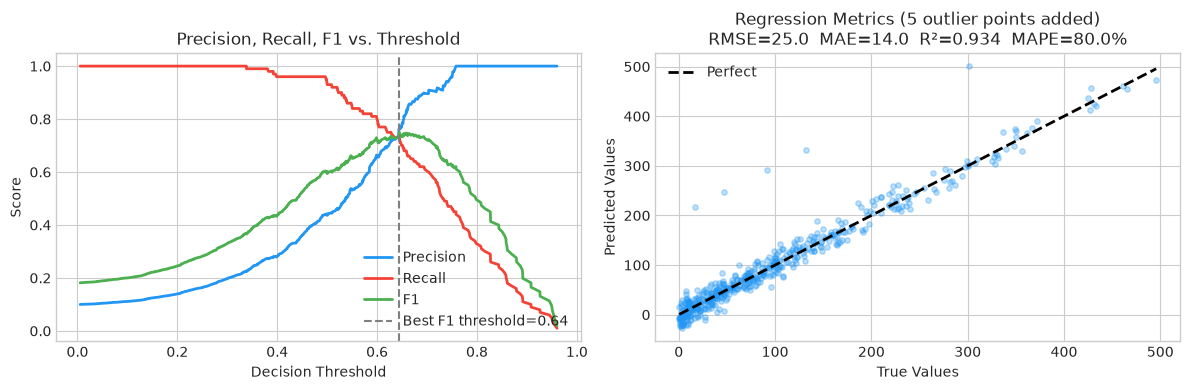

Notice: RMSE >> MAE because RMSE squares errors, making outliers dominate.
If outliers matter: use RMSE. If not: use MAE.


In [14]:
# ── Precision-Recall tradeoff curve ──────────────────────────────────────────
from sklearn.metrics import precision_recall_curve

prec_vals, rec_vals, thresh_vals = precision_recall_curve(y_true_demo, y_prob_demo)
f1_vals = 2*prec_vals[:-1]*rec_vals[:-1] / (prec_vals[:-1]+rec_vals[:-1]+1e-9)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(thresh_vals, prec_vals[:-1], color=COLORS[0], lw=2, label='Precision')
ax1.plot(thresh_vals, rec_vals[:-1],  color=COLORS[1], lw=2, label='Recall')
ax1.plot(thresh_vals, f1_vals,        color=COLORS[2], lw=2, label='F1')
best_thresh = thresh_vals[np.argmax(f1_vals)]
ax1.axvline(best_thresh, color='gray', ls='--', label=f'Best F1 threshold={best_thresh:.2f}')
ax1.set_xlabel('Decision Threshold');  ax1.set_ylabel('Score')
ax1.set_title('Precision, Recall, F1 vs. Threshold');  ax1.legend()

# Regression metrics demo
np.random.seed(42)
y_true_r = np.random.exponential(100, 500)  # positively skewed (like prices)
y_pred_r  = y_true_r + np.random.randn(500)*15

# Add some outliers
y_pred_r[0:5] = y_true_r[0:5] + 200

rmse_v = np.sqrt(mean_squared_error(y_true_r, y_pred_r))
mae_v  = mean_absolute_error(y_true_r, y_pred_r)
r2_v   = r2_score(y_true_r, y_pred_r)
mape_v = np.mean(np.abs((y_true_r - y_pred_r)/y_true_r)) * 100

ax2.scatter(y_true_r, y_pred_r, alpha=0.3, s=15, color=COLORS[0])
ax2.plot([y_true_r.min(), y_true_r.max()],
         [y_true_r.min(), y_true_r.max()], 'k--', lw=2, label='Perfect')
ax2.set_xlabel('True Values');  ax2.set_ylabel('Predicted Values')
ax2.set_title(f'Regression Metrics (5 outlier points added)\n'
               f'RMSE={rmse_v:.1f}  MAE={mae_v:.1f}  R²={r2_v:.3f}  MAPE={mape_v:.1f}%')
ax2.legend()

plt.tight_layout();  plt.show()

print("Notice: RMSE >> MAE because RMSE squares errors, making outliers dominate.")
print("If outliers matter: use RMSE. If not: use MAE.")

### INTERVIEW QUESTION
**"Explain precision vs recall to a business stakeholder."**

**Senior DS Answer:**
> I use concrete examples. For a cancer screening test: *Recall* (sensitivity) means "of all real cancer patients, what fraction did we catch?" High recall = few cancers missed. *Precision* means "of all people we flagged as having cancer, what fraction actually do?" High precision = few unnecessary biopsies.
>
> The tradeoff: to catch every cancer patient (recall=1.0), you could flag everyone — but then precision is 0.1% (the cancer rate). To never falsely alarm (precision=1.0), you only flag people who are 100% certain to have cancer — but you'd miss most cases.
>
> I ask the stakeholder: "What's more costly — missing a case, or an unnecessary action?" Missing fraud → use recall-focused model. False fraud accusation alienating customers → use precision-focused model. Then I tune the decision threshold to hit the business-optimal operating point.
>
> I never report just accuracy for any task where classes are imbalanced or costs are asymmetric.

---
## 9. Curse of Dimensionality

As dimensionality increases:
1. **Volume grows exponentially** — data becomes sparse
2. **Distances concentrate** — all points become equidistant
3. **Hyperparameter spaces explode** — optimization harder
4. **Overfitting risk increases** — more parameters relative to samples

**Why it breaks KNN:** KNN relies on finding "nearby" neighbors, but in high dimensions, all points are approximately the same distance from each other — the concept of "close neighbor" loses meaning.

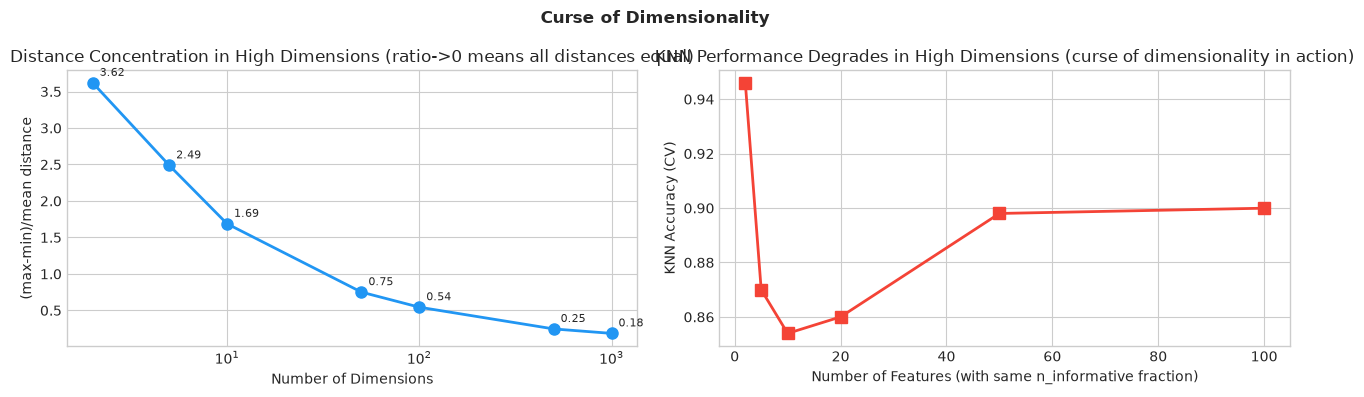

As dimensions increase → distances concentrate → KNN can't find meaningful neighbors.
Solutions: PCA/dimensionality reduction, feature selection, or use non-distance-based models.


In [15]:
# ── Distance concentration in high dimensions ────────────────────────────────
np.random.seed(42)
n_points = 1000
dimensions = [2, 5, 10, 50, 100, 500, 1000]

dist_ratios = []   # (max - min) / mean distance — measures concentration

for d in dimensions:
    X_hd = np.random.randn(n_points, d)
    # Compute pairwise distances for first 200 points
    from scipy.spatial.distance import pdist
    dists = pdist(X_hd[:200], metric='euclidean')
    ratio = (dists.max() - dists.min()) / dists.mean()
    dist_ratios.append(ratio)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.semilogx(dimensions, dist_ratios, 'o-', color=COLORS[0], lw=2, ms=8)
ax1.set_xlabel('Number of Dimensions');  ax1.set_ylabel('(max-min)/mean distance')
ax1.set_title('Distance Concentration in High Dimensions (ratio->0 means all distances equal)')
for d, r in zip(dimensions, dist_ratios):
    ax1.annotate(f'{r:.2f}', (d, r), textcoords='offset points', xytext=(5,5), fontsize=8)

# ── KNN accuracy vs dimensions ────────────────────────────────────────────────
knn_scores = []
for d in [2, 5, 10, 20, 50, 100]:
    X_knn, y_knn = make_classification(n_samples=500, n_features=d,
                                        n_informative=max(2, d//4),
                                        n_redundant=0, random_state=42)
    score = cross_val_score(KNeighborsClassifier(n_neighbors=5), X_knn, y_knn,
                             cv=3, scoring='accuracy').mean()
    knn_scores.append(score)

dims_knn = [2, 5, 10, 20, 50, 100]
ax2.plot(dims_knn, knn_scores, 's-', color=COLORS[1], lw=2, ms=8)
ax2.set_xlabel('Number of Features (with same n_informative fraction)')
ax2.set_ylabel('KNN Accuracy (CV)')
ax2.set_title('KNN Performance Degrades in High Dimensions (curse of dimensionality in action)')

plt.suptitle('Curse of Dimensionality', fontsize=12, fontweight='bold')
plt.tight_layout();  plt.show()

print("As dimensions increase → distances concentrate → KNN can't find meaningful neighbors.")
print("Solutions: PCA/dimensionality reduction, feature selection, or use non-distance-based models.")

### INTERVIEW QUESTION
**"What is the curse of dimensionality and how do you deal with it?"**

**Senior DS Answer:**
> The curse of dimensionality describes how high-dimensional spaces behave counterintuitively. The key phenomenon is distance concentration: as dimensions increase, the ratio of maximum to minimum pairwise distance approaches 1 — all points become equidistant. This destroys distance-based methods like KNN.
>
> There's also the volume problem: to maintain the same data density, you need exponentially more samples as dimensions grow. With 10 features needing 10 samples each per bin, you'd need 10^10 samples for a naive grid — impossible.
>
> Solutions: (1) **Dimensionality reduction** — PCA, t-SNE for visualization, UMAP; (2) **Feature selection** — remove irrelevant features; (3) **Regularization** — constrains the effective dimensionality; (4) **Use models that handle it** — tree-based models and neural networks are less affected than KNN or kernel SVMs; (5) **Collect more data** — but this is exponentially harder than reducing dimensions.
>
> Practical threshold: once features >> samples (p >> n), be very cautious. In genetics (p=50,000, n=500), you must do dimensionality reduction before any distance-based analysis.

---
## 10. No Free Lunch Theorem

**Statement (Wolpert & Macready, 1997):** Averaged over all possible problems, no learning algorithm performs better than any other — including random guessing.

**Practical implication:** There is no universally best algorithm. A model that works perfectly on one problem will underperform on another. This is why we:
1. Try multiple algorithms on every new problem
2. Use domain knowledge to constrain the hypothesis space
3. Treat model selection as an empirical question, not a theoretical one

**But:** The theorem applies to *all* possible problems with equal probability — most real-world problems share structure (smoothness, locality, inductive biases that match our models), which is why gradient boosting works well in practice on many tabular problems.

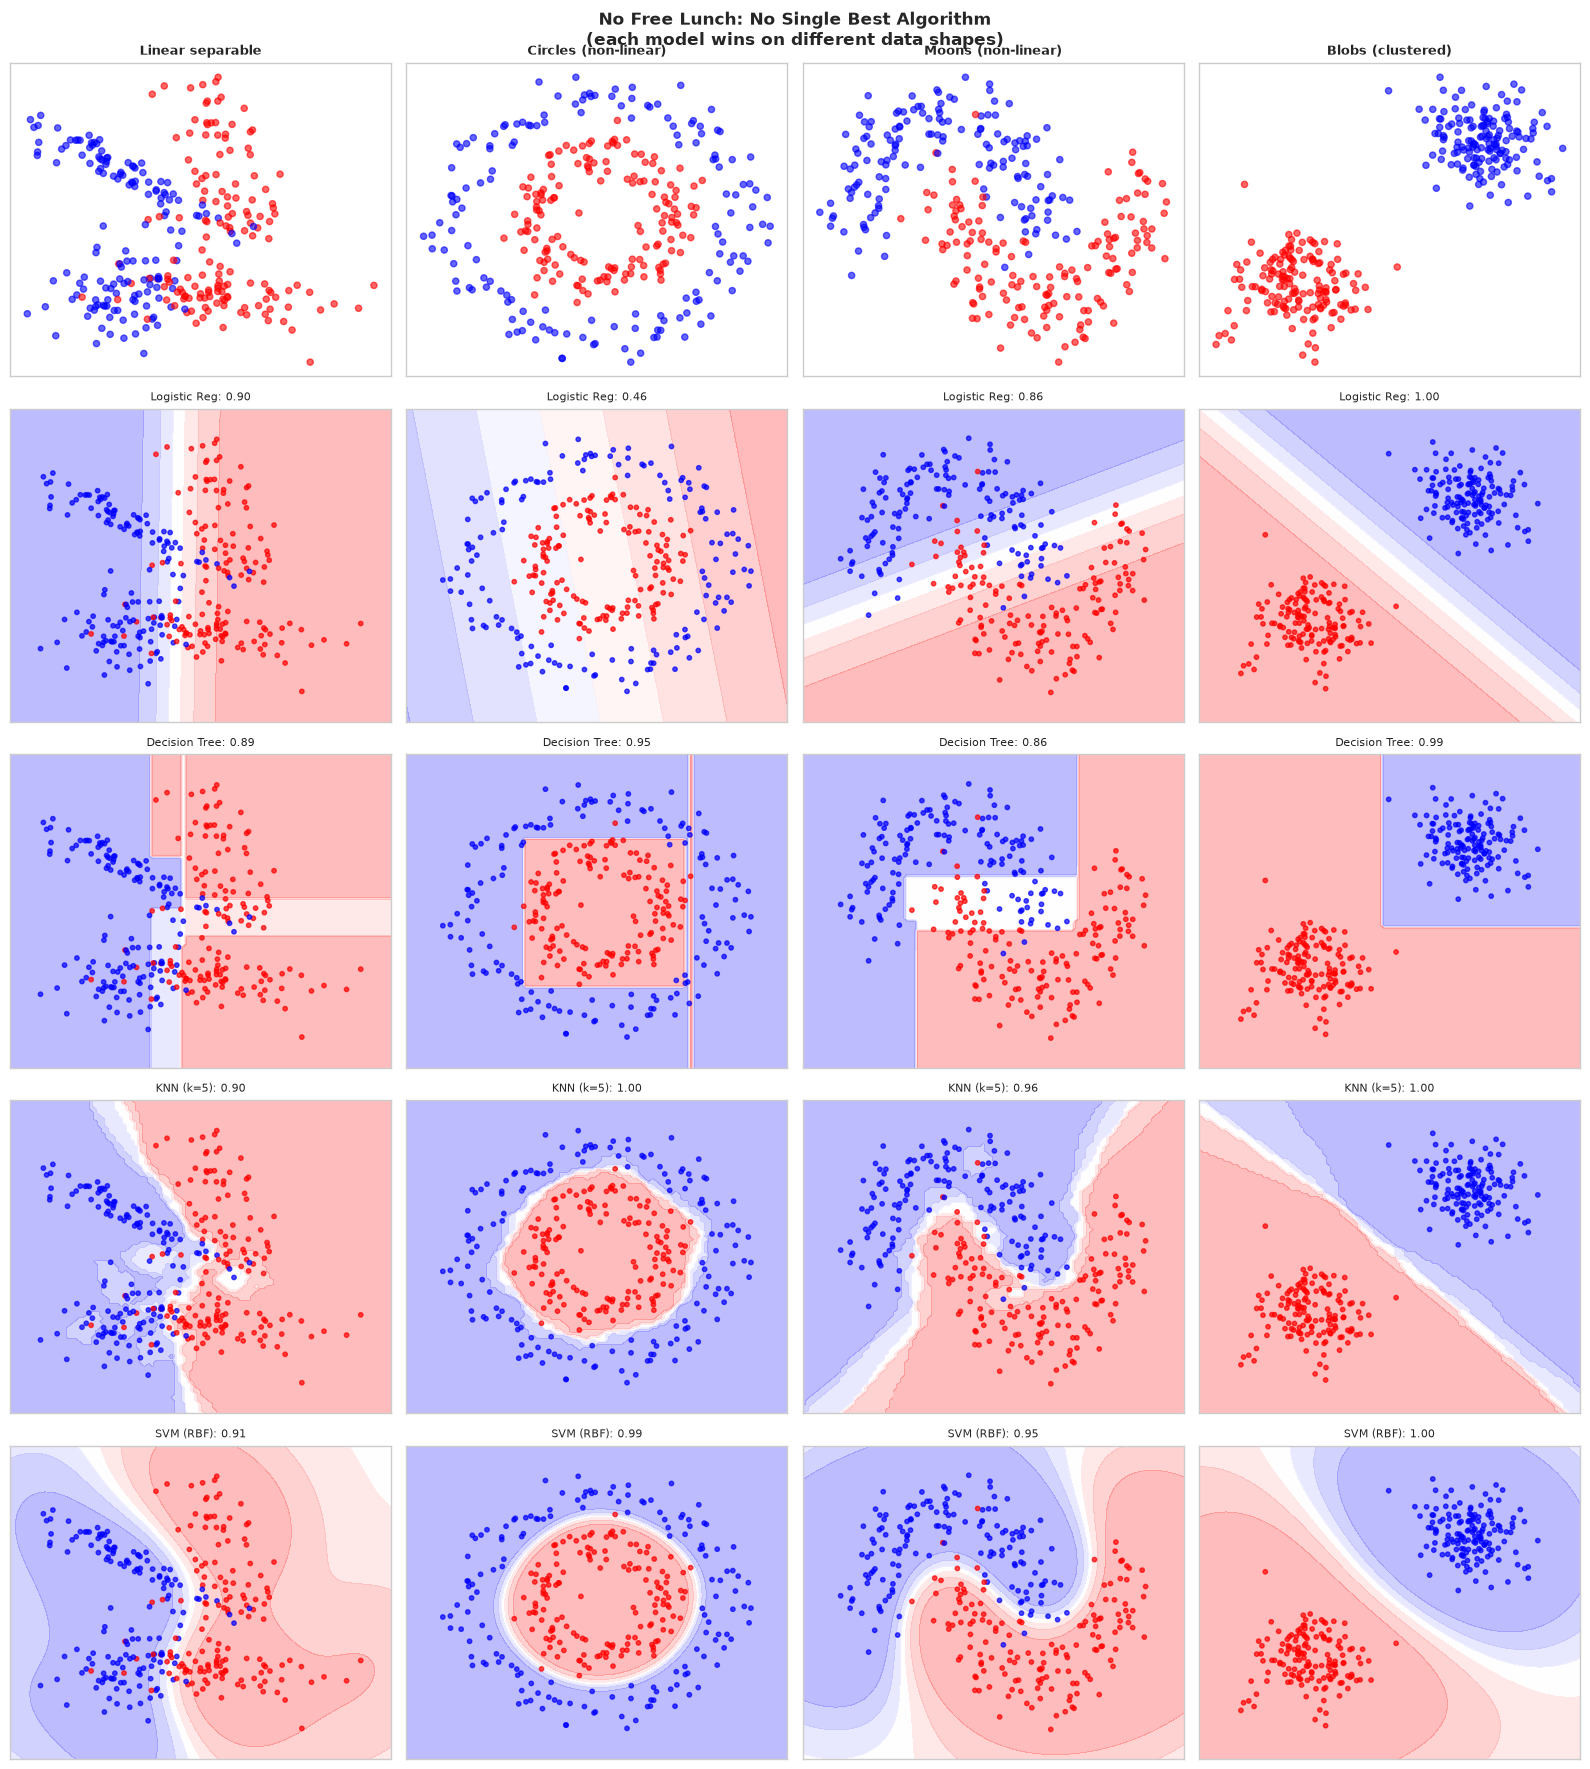


Accuracy scores:
               Linear separable  Circles (non-linear)  Moons (non-linear)  Blobs (clustered)
Logistic Reg              0.897                 0.457               0.857               1.00
Decision Tree             0.890                 0.947               0.863               0.99
KNN (k=5)                 0.903                 0.997               0.960               1.00
SVM (RBF)                 0.907                 0.990               0.953               1.00

→ No single model wins on all datasets. Always compare multiple algorithms!


In [16]:
# ── No Free Lunch: same algorithm, different datasets ────────────────────────
np.random.seed(42)

datasets = {
    'Linear separable':      make_classification(n_samples=300, n_features=2,
                               n_informative=2, n_redundant=0, random_state=1),
    'Circles (non-linear)':  make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=1),
    'Moons (non-linear)':    __import__('sklearn.datasets', fromlist=['make_moons']).make_moons(
                               n_samples=300, noise=0.2, random_state=1),
    'Blobs (clustered)':     __import__('sklearn.datasets', fromlist=['make_blobs']).make_blobs(
                               n_samples=300, centers=2, cluster_std=1.5, random_state=1),
}

models = {
    'Logistic Reg': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=42),
    'KNN (k=5)':    KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)':    SVC(kernel='rbf', C=1.0, probability=True),
}

fig, axes = plt.subplots(len(models)+1, len(datasets), figsize=(16, 18))

# Header row: dataset scatter
for col, (ds_name, (X_ds, y_ds)) in enumerate(datasets.items()):
    axes[0, col].scatter(X_ds[:,0], X_ds[:,1], c=y_ds, cmap='bwr', alpha=0.6, s=20)
    axes[0, col].set_title(ds_name, fontweight='bold', fontsize=9)
    axes[0, col].set_xticks([]);  axes[0, col].set_yticks([])

scores_table = {}
for row, (m_name, model) in enumerate(models.items()):
    scores_table[m_name] = {}
    for col, (ds_name, (X_ds, y_ds)) in enumerate(datasets.items()):
        scaler_nfl = StandardScaler()
        X_s = scaler_nfl.fit_transform(X_ds)
        score = cross_val_score(model, X_s, y_ds, cv=5, scoring='accuracy').mean()
        scores_table[m_name][ds_name] = score

        # Decision boundary
        ax = axes[row+1, col]
        model_fit = model.__class__(**model.get_params()).fit(X_s, y_ds)
        xx, yy = np.meshgrid(np.linspace(X_s[:,0].min()-0.5, X_s[:,0].max()+0.5, 100),
                              np.linspace(X_s[:,1].min()-0.5, X_s[:,1].max()+0.5, 100))
        try:
            Z = model_fit.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)
        except:
            Z = model_fit.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        ax.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
        ax.scatter(X_s[:,0], X_s[:,1], c=y_ds, cmap='bwr', s=10, alpha=0.7)
        ax.set_title(f'{m_name}: {score:.2f}', fontsize=8)
        ax.set_xticks([]);  ax.set_yticks([])

plt.suptitle('No Free Lunch: No Single Best Algorithm\n(each model wins on different data shapes)',
             fontsize=12, fontweight='bold')
plt.tight_layout();  plt.show()

# Print scores table
print("\nAccuracy scores:")
df_nfl = pd.DataFrame(scores_table).T
print(df_nfl.round(3).to_string())
print("\n→ No single model wins on all datasets. Always compare multiple algorithms!")

### INTERVIEW QUESTION
**"What is the No Free Lunch Theorem and why does it matter in practice?"**

**Senior DS Answer:**
> The NFL theorem proves mathematically that no algorithm is universally superior — averaged over all possible problem distributions, every algorithm performs identically, including random guessing. In pure theory, there's no basis to prefer gradient boosting over a coin flip.
>
> In practice, it means: never assume your favorite algorithm will work. Real-world problems aren't drawn from a random distribution — they share structure like smoothness, locality, and patterns our inductive biases match. That's why gradient boosting happens to win many Kaggle tabular competitions.
>
> The practical workflow it dictates: always run a baseline comparison of 3-5 algorithms before committing to one. I typically benchmark: logistic regression (interpretable baseline), random forest (strong, few assumptions), gradient boosting (often best tabular), SVM (good for high-dimensional), and one simple model (dummy classifier). The winner is an empirical question, not a theoretical one. The theorem also justifies why AutoML exists.

---
## 11. Gradient Descent Variants

| Variant | Update uses | Pros | Cons |
|---|---|---|---|
| Batch GD | Full dataset | Exact gradient, stable | Slow for large N, can't stream |
| SGD | 1 sample | Fast per step, online learning | Noisy, can oscillate |
| Mini-batch GD | Batch of B samples | Balanced speed/stability | Needs batch size tuning |
| SGD + Momentum | EMA of gradients | Escapes shallow minima | Extra hyperparameter |
| Adam | Adaptive per-param LR | Fast convergence, robust | Can overfit, memory cost |

### Key formulas

**Momentum:** $v_t = \beta v_{t-1} + \nabla L$ ; $\theta_t = \theta_{t-1} - \alpha v_t$

**Adam:** $m_t = \beta_1 m_{t-1} + (1-\beta_1)\nabla L$ (first moment)  
$v_t = \beta_2 v_{t-1} + (1-\beta_2)(\nabla L)^2$ (second moment)  
$\theta_t = \theta_{t-1} - \frac{\alpha \hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$

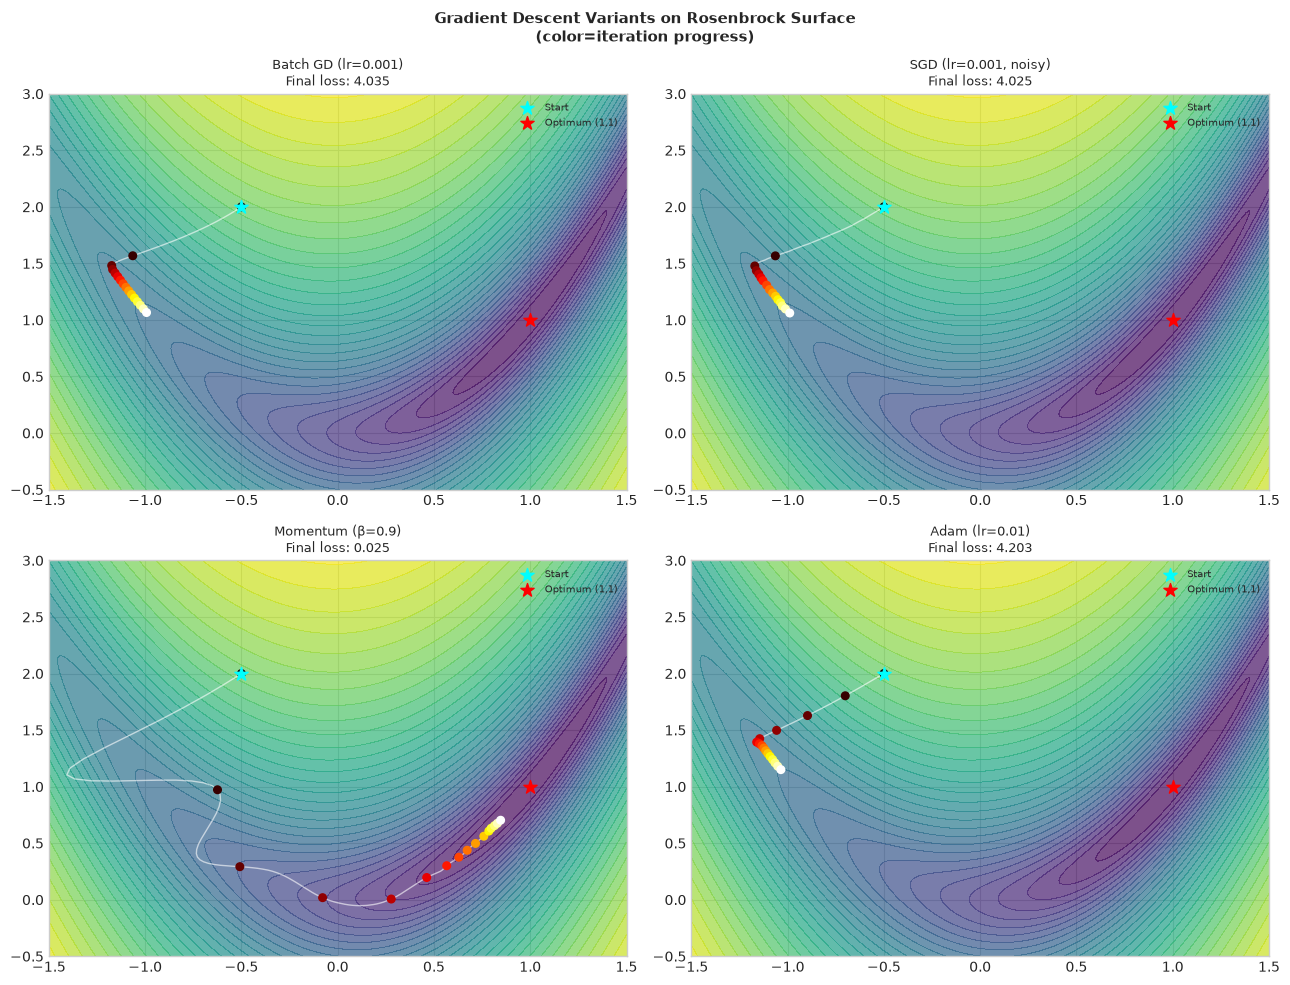

Final loss values (lower = better convergence in 300 steps):
  Batch GD (lr=0.001)                : 4.0352
  SGD (lr=0.001, noisy)              : 4.0254
  Momentum (β=0.9)                   : 0.0254
  Adam (lr=0.01)                     : 4.2033


In [17]:
# ── Gradient descent variants on a loss surface ──────────────────────────────
np.random.seed(42)

# 2D Rosenbrock-like loss surface (banana-shaped, illustrates momentum benefit)
def loss(w1, w2):
    return (1 - w1)**2 + 10*(w2 - w1**2)**2

def grad(w1, w2):
    dw1 = -2*(1 - w1) - 40*w1*(w2 - w1**2)
    dw2 = 20*(w2 - w1**2)
    return np.array([dw1, dw2])

# Add noise for SGD
def noisy_grad(w1, w2, noise=0.5):
    return grad(w1, w2) + np.random.randn(2)*noise

def run_gd(start, lr, steps, noise_level=0.0, beta=0.0, adaptive=False):
    w = np.array(start, dtype=float);  path = [w.copy()]
    v = np.zeros(2);  m = np.zeros(2);  vv = np.zeros(2);  t = 0
    eps = 1e-8;  beta2 = 0.999
    for _ in range(steps):
        g = noisy_grad(w[0], w[1], noise_level)
        if adaptive:  # Adam
            t += 1
            m = 0.9*m + 0.1*g;  vv = beta2*vv + (1-beta2)*g**2
            mh = m/(1-0.9**t);   vvh = vv/(1-beta2**t)
            w -= lr * mh / (np.sqrt(vvh) + eps)
        elif beta > 0:  # Momentum
            v = beta*v + g;  w -= lr*v
        else:  # Vanilla
            w -= lr*g
        path.append(w.copy())
    return np.array(path)

start = [-0.5, 2.0]
paths = {
    'Batch GD (lr=0.001)':   run_gd(start, 0.001, 300, noise_level=0.0),
    'SGD (lr=0.001, noisy)': run_gd(start, 0.001, 300, noise_level=1.0),
    'Momentum (β=0.9)':      run_gd(start, 0.001, 300, noise_level=0.3, beta=0.9),
    'Adam (lr=0.01)':        run_gd(start, 0.01,  300, noise_level=0.3, adaptive=True),
}

# Loss surface
w1_range = np.linspace(-1.5, 1.5, 200)
w2_range = np.linspace(-0.5, 3.0, 200)
W1, W2 = np.meshgrid(w1_range, w2_range)
Z = loss(W1, W2)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (name, path) in zip(axes, paths.items()):
    ax.contourf(W1, W2, np.log1p(Z), levels=30, cmap='viridis', alpha=0.7)
    ax.plot(path[:,0], path[:,1], 'w-', lw=1, alpha=0.6)
    ax.scatter(path[::20, 0], path[::20, 1], c=range(len(path[::20])),
               cmap='hot', s=30, zorder=5)
    ax.scatter(path[0,0], path[0,1], c='cyan', s=100, marker='*', zorder=6, label='Start')
    ax.scatter(1, 1, c='red', s=100, marker='*', zorder=6, label='Optimum (1,1)')
    final_loss = loss(path[-1,0], path[-1,1])
    ax.set_title(f'{name}\nFinal loss: {final_loss:.3f}', fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Gradient Descent Variants on Rosenbrock Surface\n(color=iteration progress)',
             fontsize=11, fontweight='bold')
plt.tight_layout();  plt.show()

# Print convergence comparison
print("Final loss values (lower = better convergence in 300 steps):")
for name, path in paths.items():
    fl = loss(path[-1,0], path[-1,1])
    print(f"  {name:<35}: {fl:.4f}")

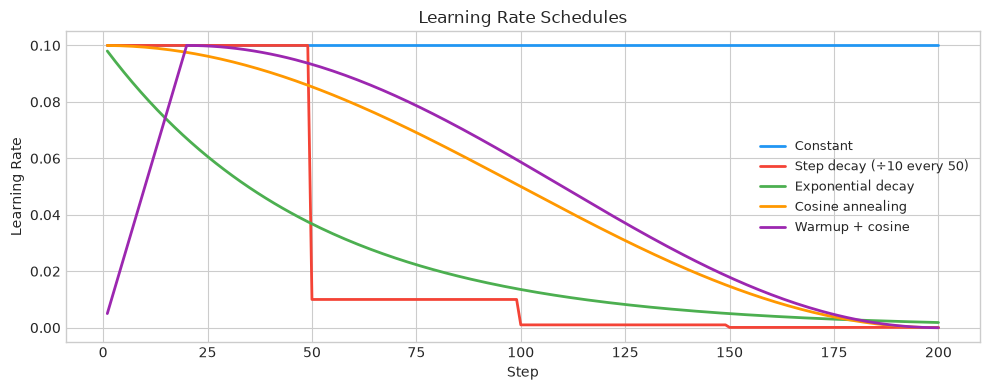

When to use each:
  Constant:          Simple baselines, already well-tuned
  Step/Exp decay:    When you know roughly when to reduce LR
  Cosine annealing:  Neural networks — smooth, works well
  Warmup + cosine:   Transformers / large models — prevents early instability


In [18]:
# ── Learning rate schedules ───────────────────────────────────────────────────
steps_lr = np.arange(1, 201)
lr_init = 0.1

schedules = {
    'Constant':         np.full_like(steps_lr, lr_init, dtype=float),
    'Step decay (÷10 every 50)': lr_init * (0.1 ** (steps_lr // 50)),
    'Exponential decay': lr_init * np.exp(-0.02 * steps_lr),
    'Cosine annealing': lr_init/2 * (1 + np.cos(np.pi * steps_lr / steps_lr.max())),
    'Warmup + cosine':  np.where(steps_lr < 20,
                                  lr_init * steps_lr/20,
                                  lr_init/2*(1+np.cos(np.pi*(steps_lr-20)/(steps_lr.max()-20)))),
}

fig, ax = plt.subplots(figsize=(10, 4))
for (name, lr_vals), color in zip(schedules.items(), COLORS):
    ax.plot(steps_lr, lr_vals, lw=2, label=name, color=color)
ax.set_xlabel('Step');  ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedules')
ax.legend(fontsize=9)
plt.tight_layout();  plt.show()

print("When to use each:")
print("  Constant:          Simple baselines, already well-tuned")
print("  Step/Exp decay:    When you know roughly when to reduce LR")
print("  Cosine annealing:  Neural networks — smooth, works well")
print("  Warmup + cosine:   Transformers / large models — prevents early instability")

### INTERVIEW QUESTION
**"Explain the difference between SGD and Adam. When would you use each?"**

**Senior DS Answer:**
> SGD updates parameters using the gradient from one (or a mini-batch of) training example(s). It's noisy but cheap and can generalize better because the noise acts as implicit regularization — it helps escape sharp minima. The downside is sensitivity to learning rate and slow convergence on curved loss surfaces.
>
> Adam maintains a running average of gradients (first moment) and squared gradients (second moment), computing a per-parameter adaptive learning rate. This makes it robust to different feature scales and converges much faster on ill-conditioned problems.
>
> **When to use:** Adam for neural networks — it's forgiving and fast to converge, especially useful early in development. SGD + momentum for final model training in production neural networks — there's empirical evidence it generalizes better (flatter minima). For linear models and gradient boosting, use the framework's built-in optimizer (usually LBFGS or Newton's method).
>
> The key interview point: Adam's fast convergence is actually a double-edged sword — it can find sharp, narrow minima that don't generalize as well as the flatter minima SGD stumbles into.

---
## 12. Hyperparameter Tuning

| Method | Strategy | Pros | Cons |
|---|---|---|---|
| Grid Search | Exhaustive grid | Reproducible, complete | Exponential in #params |
| Random Search | Random samples | Often as good, much faster | Non-deterministic |
| Bayesian Optimization | Sequential, uses posterior | Best for expensive evals | Complex, less parallizable |

**Why Random >> Grid:** If only 2 of 9 hyperparameters matter, random search tries 9 different values of each important param, while grid search might try the same 3 values of each param 3 times.

In [19]:
# ── Grid vs Random vs Bayesian search comparison ─────────────────────────────
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint, uniform
import time

X_ht, y_ht = make_classification(n_samples=1000, n_features=20,
                                   n_informative=8, random_state=42)
X_tr_ht, X_te_ht, y_tr_ht, y_te_ht = train_test_split(X_ht, y_ht, test_size=0.2, random_state=42)

# Grid Search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
}
t0 = time.time()
gs = GridSearchCV(RandomForestClassifier(random_state=42), param_grid,
                   cv=3, scoring='roc_auc', n_jobs=-1)
gs.fit(X_tr_ht, y_tr_ht)
gs_time = time.time() - t0
gs_results = pd.DataFrame(gs.cv_results_)

# Random Search (same parameter space, 20 iterations)
param_dist = {
    'n_estimators': randint(10, 300),
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': randint(2, 20),
    'max_features': uniform(0.3, 0.7),
}
t0 = time.time()
rs = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_dist,
                         n_iter=20, cv=3, scoring='roc_auc', n_jobs=-1, random_state=42)
rs.fit(X_tr_ht, y_tr_ht)
rs_time = time.time() - t0
rs_results = pd.DataFrame(rs.cv_results_)

print(f"Grid Search:   {len(gs_results)} combinations evaluated in {gs_time:.1f}s")
print(f"  Best CV AUC: {gs.best_score_:.4f}  |  Test AUC: {roc_auc_score(y_te_ht, gs.best_estimator_.predict_proba(X_te_ht)[:,1]):.4f}")
print(f"  Best params: {gs.best_params_}")
print()
print(f"Random Search: {len(rs_results)} combinations evaluated in {rs_time:.1f}s")
print(f"  Best CV AUC: {rs.best_score_:.4f}  |  Test AUC: {roc_auc_score(y_te_ht, rs.best_estimator_.predict_proba(X_te_ht)[:,1]):.4f}")
print(f"  Best params: {rs.best_params_}")
print()
print(f"Random search achieved similar AUC in {rs_time/gs_time:.1%} of the time!")

Grid Search:   36 combinations evaluated in 17.3s
  Best CV AUC: 0.9097  |  Test AUC: 0.9296
  Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Random Search: 20 combinations evaluated in 19.6s
  Best CV AUC: 0.9156  |  Test AUC: 0.9541
  Best params: {'max_depth': None, 'max_features': np.float64(0.7207805082202461), 'min_samples_split': 4, 'n_estimators': 159}

Random search achieved similar AUC in 113.4% of the time!


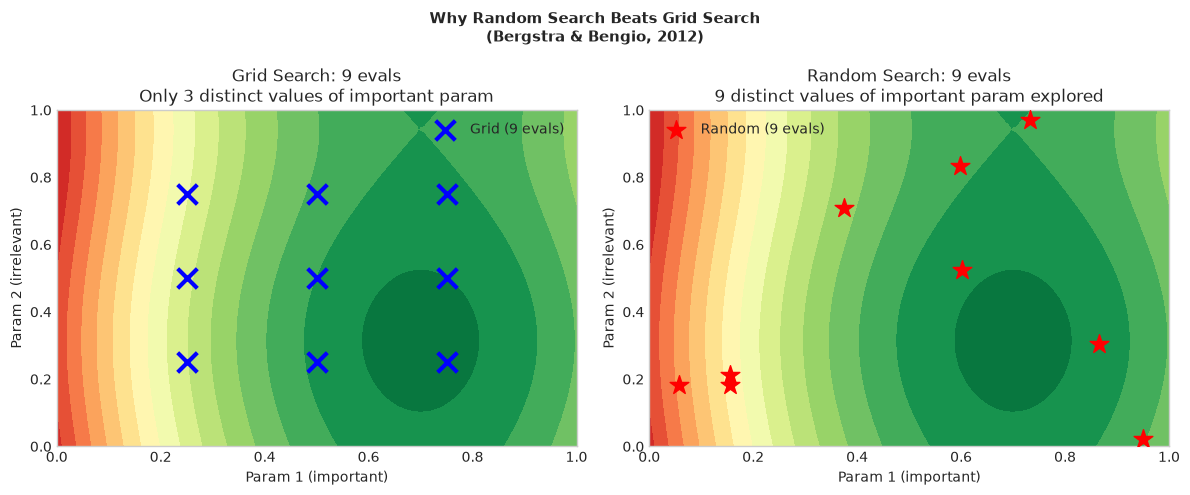

In [20]:
# ── Why Random > Grid: 2-important-params illustration ──────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Simulate a loss surface where only param1 matters
np.random.seed(42)
p1 = np.linspace(0, 1, 100)   # important
p2 = np.linspace(0, 1, 100)   # irrelevant
P1, P2 = np.meshgrid(p1, p2)
# Loss depends mainly on p1, barely on p2
Z_ht = -(4*(P1-0.7)**2) + 0.1*np.sin(5*P2) + 1.0

ax1.contourf(P1, P2, Z_ht, levels=20, cmap='RdYlGn')
# Grid: 3x3 = 9 evaluations → only 3 distinct p1 values tested
grid_p1 = [0.25, 0.5, 0.75]*3;  grid_p2 = [0.25]*3 + [0.5]*3 + [0.75]*3
ax1.scatter(grid_p1, grid_p2, s=200, c='blue', marker='x', lw=3, label='Grid (9 evals)')
ax1.set_xlabel('Param 1 (important)');  ax1.set_ylabel('Param 2 (irrelevant)')
ax1.set_title('Grid Search: 9 evals\nOnly 3 distinct values of important param')
ax1.legend()

ax2.contourf(P1, P2, Z_ht, levels=20, cmap='RdYlGn')
# Random: 9 evaluations → 9 distinct p1 values tested
rand_p1 = np.random.rand(9);  rand_p2 = np.random.rand(9)
ax2.scatter(rand_p1, rand_p2, s=200, c='red', marker='*', zorder=5, label='Random (9 evals)')
ax2.set_xlabel('Param 1 (important)');  ax2.set_ylabel('Param 2 (irrelevant)')
ax2.set_title('Random Search: 9 evals\n9 distinct values of important param explored')
ax2.legend()

plt.suptitle("Why Random Search Beats Grid Search\n(Bergstra & Bengio, 2012)",
             fontsize=11, fontweight='bold')
plt.tight_layout();  plt.show()

### INTERVIEW QUESTION
**"Why is Bayesian optimization better than grid/random search?"**

**Senior DS Answer:**
> Grid and random search are embarrassingly parallel but dumb — they don't use the results of previous evaluations to decide where to search next. Bayesian optimization is sequential and smart.
>
> It works by maintaining a **surrogate model** (typically a Gaussian Process) of the objective function, then using an **acquisition function** (like Expected Improvement) to decide which hyperparameters to try next — balancing exploration (uncertain regions) with exploitation (known good regions).
>
> The practical win: for expensive-to-evaluate models (neural networks, gradient boosting with many iterations), each evaluation takes minutes. Bayesian optimization typically finds better configurations in 20-50 evaluations than random search needs in 100-200. Libraries like Optuna, Hyperopt, or scikit-optimize implement this.
>
> When to use what: Grid search only when the space is tiny (<20 combinations). Random search for moderate spaces when you can parallelize. Bayesian optimization when each evaluation is expensive (>1 minute) and you have a budget of <100 evaluations.

---
## 13. Ensemble Methods Theory

### Why ensembles work: Variance Reduction

If $n$ independent models each have error variance $\sigma^2$, averaging reduces variance to $\sigma^2/n$.  
In practice, models are correlated (reducing this benefit), so diversity is key.

| Method | Mechanism | Reduces | Base learners | Example |
|---|---|---|---|---|
| **Bagging** | Bootstrap resample + avg | Variance | Parallel, high-variance | Random Forest |
| **Boosting** | Sequential, reweight errors | Bias + some variance | Sequential, weak | XGBoost, AdaBoost |
| **Stacking** | Meta-learner on predictions | Both | Diverse | Blend of RF+LR+SVM |
| **Voting** | Majority vote / average | Variance | Diverse | VotingClassifier |

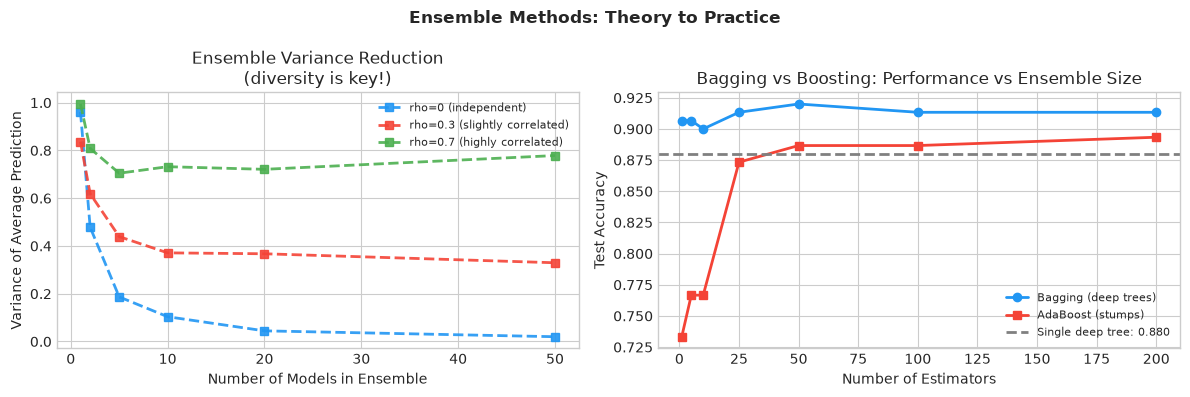

In [21]:
# -- Variance reduction through averaging ----------------------------------------
np.random.seed(42)

n_models_range = [1, 2, 5, 10, 20, 50]
individual_var = 1.0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for rho, color, label in [(0.0, COLORS[0], 'rho=0 (independent)'),
                           (0.3, COLORS[1], 'rho=0.3 (slightly correlated)'),
                           (0.7, COLORS[2], 'rho=0.7 (highly correlated)')]:
    empirical_var = []
    for n in n_models_range:
        preds_matrix = []
        for _ in range(500):
            cov = np.full((n, n), rho) + np.eye(n)*(1-rho)
            preds = np.random.multivariate_normal(np.zeros(n), cov)
            preds_matrix.append(preds.mean())
        empirical_var.append(np.var(preds_matrix))
    axes[0].plot(n_models_range, empirical_var, 's--', color=color, lw=2, alpha=0.9, label=label)

axes[0].set_xlabel('Number of Models in Ensemble')
axes[0].set_ylabel('Variance of Average Prediction')
axes[0].set_title('Ensemble Variance Reduction\n(diversity is key!)')
axes[0].legend(fontsize=8)

# -- Bagging vs Boosting performance vs ensemble size --------------------------
X_ens, y_ens = make_classification(n_samples=500, n_features=10,
                                    n_informative=5, random_state=42)
X_tr_ens, X_te_ens, y_tr_ens, y_te_ens = train_test_split(
    X_ens, y_ens, test_size=0.3, random_state=42)

n_est_range = [1, 5, 10, 25, 50, 100, 200]
bag_scores, boost_scores = [], []

for n in n_est_range:
    bag = BaggingClassifier(DecisionTreeClassifier(max_depth=None),
                             n_estimators=n, random_state=42).fit(X_tr_ens, y_tr_ens)
    boost = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1),
                                n_estimators=n, random_state=42).fit(X_tr_ens, y_tr_ens)
    bag_scores.append(bag.score(X_te_ens, y_te_ens))
    boost_scores.append(boost.score(X_te_ens, y_te_ens))

single_score = DecisionTreeClassifier(max_depth=None, random_state=42).fit(
    X_tr_ens, y_tr_ens).score(X_te_ens, y_te_ens)

axes[1].plot(n_est_range, bag_scores,   'o-', color=COLORS[0], lw=2, ms=6, label='Bagging (deep trees)')
axes[1].plot(n_est_range, boost_scores, 's-', color=COLORS[1], lw=2, ms=6, label='AdaBoost (stumps)')
axes[1].axhline(single_score, color='gray', ls='--', lw=2, label=f'Single deep tree: {single_score:.3f}')
axes[1].set_xlabel('Number of Estimators');  axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Bagging vs Boosting: Performance vs Ensemble Size')
axes[1].legend(fontsize=8)

plt.suptitle('Ensemble Methods: Theory to Practice', fontsize=12, fontweight='bold')
plt.tight_layout();  plt.show()

Model comparison (5-fold CV AUC-ROC):
  Logistic Regression      : 0.9160 +/- 0.0213
  Decision Tree            : 0.8594 +/- 0.0322
  KNN                      : 0.9879 +/- 0.0058


  Random Forest            : 0.9803 +/- 0.0066


  Gradient Boosting        : 0.9767 +/- 0.0072


  Stacking                 : 0.9918 +/- 0.0056


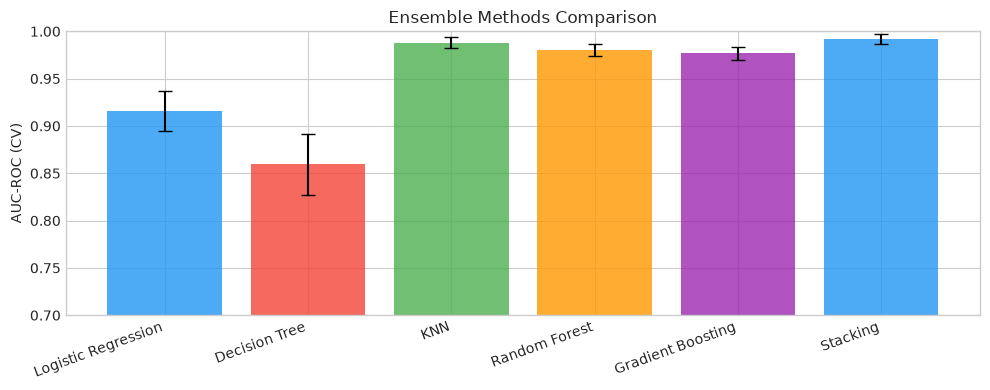

In [22]:
# -- Stacking demonstration -------------------------------------------------------
from sklearn.ensemble import StackingClassifier

X_stk, y_stk = make_classification(n_samples=1000, n_features=20,
                                     n_informative=10, random_state=42)

base_learners = [
    ('lr',  LogisticRegression(max_iter=1000, C=0.1)),
    ('dt',  DecisionTreeClassifier(max_depth=4, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=7)),
    ('svm', SVC(probability=True, kernel='rbf', C=1.0)),
]
meta = LogisticRegression(max_iter=1000)
stacker = StackingClassifier(estimators=base_learners, final_estimator=meta, cv=5)

models_cmp = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=0.1),
    'Decision Tree':       DecisionTreeClassifier(max_depth=4, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=7),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Stacking':            stacker,
}

print("Model comparison (5-fold CV AUC-ROC):")
auc_scores = {}
for name, clf in models_cmp.items():
    score = cross_val_score(clf, X_stk, y_stk, cv=5, scoring='roc_auc', n_jobs=-1)
    auc_scores[name] = score
    print(f"  {name:<25}: {score.mean():.4f} +/- {score.std():.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
names_sorted = list(auc_scores.keys())
means = [auc_scores[n].mean() for n in names_sorted]
stds  = [auc_scores[n].std()  for n in names_sorted]
colors_bar = [COLORS[i % len(COLORS)] for i in range(len(names_sorted))]
ax.bar(names_sorted, means, yerr=stds, capsize=5, color=colors_bar, alpha=0.8)
ax.set_ylabel('AUC-ROC (CV)');  ax.set_title('Ensemble Methods Comparison')
ax.set_xticklabels(names_sorted, rotation=20, ha='right')
ax.set_ylim(0.7, 1.0)
plt.tight_layout();  plt.show()

### INTERVIEW QUESTION
**"Explain the difference between bagging and boosting. Which reduces bias vs variance?"**

**Senior DS Answer:**
> **Bagging** (Bootstrap AGGregating) trains independent models in parallel on bootstrap samples. Each model has high variance individually, but averaging them reduces variance while keeping bias roughly the same. Random Forest applies bagging to decision trees plus random feature subsets at each split, further decorrelating trees.
>
> **Boosting** trains models sequentially, with each model focusing on the mistakes of the previous one. Gradient boosting fits each new model to the pseudo-residuals of the ensemble so far. Boosting reduces both bias and variance, but risks overfitting if run too long.
>
> **Key rule:** Bagging works best with high-variance, low-bias base models (deep trees). Boosting works best with low-variance, high-bias base models (shallow stumps). Random Forest = Bagging + deep trees. XGBoost = Boosting + shallow trees + regularization.
>
> **Stacking** uses a meta-learner to learn how to weight base models. Works when models have complementary strengths, but adds leakage risk — the meta-learner must be trained on out-of-fold predictions, not in-fold predictions from the same data.

---
## 14. Train/Val/Test Split Best Practices

### Why 3-way split?

| Set | Purpose | Who touches it? |
|---|---|---|
| **Train** | Fit model parameters | Model during training |
| **Validation** | Tune hyperparameters, select features | You during development |
| **Test** | Estimate real-world performance | Once, at the very end |

**The fundamental rule:** The test set must never influence any decision during development. If you use test performance to select between models, you've effectively trained on the test set — your performance estimate is optimistic.

### Nested CV: for small datasets

Outer CV loop estimates unbiased generalization error. Inner CV loop handles hyperparameter tuning.

In [23]:
# -- Test set contamination demonstration -------------------------------------
np.random.seed(42)
X_cont, y_cont = make_classification(n_samples=200, n_features=50,
                                      n_informative=3, n_redundant=0, random_state=42)

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_cont, y_cont, test_size=0.3, random_state=42)

# WRONG: fit feature selector on all data including test
selector_bad2 = SelectKBest(f_classif, k=10).fit(X_cont, y_cont)  # LEAKS test!
X_tr_bad = selector_bad2.transform(X_tr_c)
X_te_bad = selector_bad2.transform(X_te_c)
lr_bad2  = LogisticRegression(max_iter=1000).fit(X_tr_bad, y_tr_c)
score_contaminated = lr_bad2.score(X_te_bad, y_te_c)

# CORRECT: fit feature selector only on training data
selector_good2 = SelectKBest(f_classif, k=10).fit(X_tr_c, y_tr_c)  # Only train!
X_tr_good = selector_good2.transform(X_tr_c)
X_te_good = selector_good2.transform(X_te_c)
lr_good2  = LogisticRegression(max_iter=1000).fit(X_tr_good, y_tr_c)
score_correct = lr_good2.score(X_te_good, y_te_c)

print("Test Set Contamination via Feature Selection:")
print(f"  WRONG (feature select on ALL data): Test accuracy = {score_contaminated:.4f}")
print(f"  CORRECT (feature select on train):  Test accuracy = {score_correct:.4f}")
print(f"  Inflation = {score_contaminated - score_correct:.4f} -- false sense of performance!")
print()

# -- Nested CV ----------------------------------------------------------------
X_nested, y_nested = make_classification(n_samples=300, n_features=20,
                                          n_informative=5, random_state=42)

inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)
outer_cv  = KFold(n_splits=5, shuffle=True, random_state=42)
param_grid_nest = {'max_depth': [3, 5, 7], 'n_estimators': [50, 100]}

gs_inner = GridSearchCV(RandomForestClassifier(random_state=42),
                         param_grid_nest, cv=inner_cv, scoring='roc_auc')
gs_inner.fit(X_nested, y_nested)
non_nested_score = gs_inner.best_score_

nested_scores = cross_val_score(gs_inner, X_nested, y_nested,
                                 cv=outer_cv, scoring='roc_auc')

print("Non-Nested vs Nested Cross-Validation:")
print(f"  Non-nested CV (optimistic): {non_nested_score:.4f}")
print(f"  Nested CV (unbiased):       {nested_scores.mean():.4f} +/- {nested_scores.std():.4f}")
print(f"  Optimism bias = {non_nested_score - nested_scores.mean():.4f}")

Test Set Contamination via Feature Selection:
  WRONG (feature select on ALL data): Test accuracy = 0.9333
  CORRECT (feature select on train):  Test accuracy = 0.9167
  Inflation = 0.0167 -- false sense of performance!



Non-Nested vs Nested Cross-Validation:
  Non-nested CV (optimistic): 0.9231
  Nested CV (unbiased):       0.9298 +/- 0.0139
  Optimism bias = -0.0067


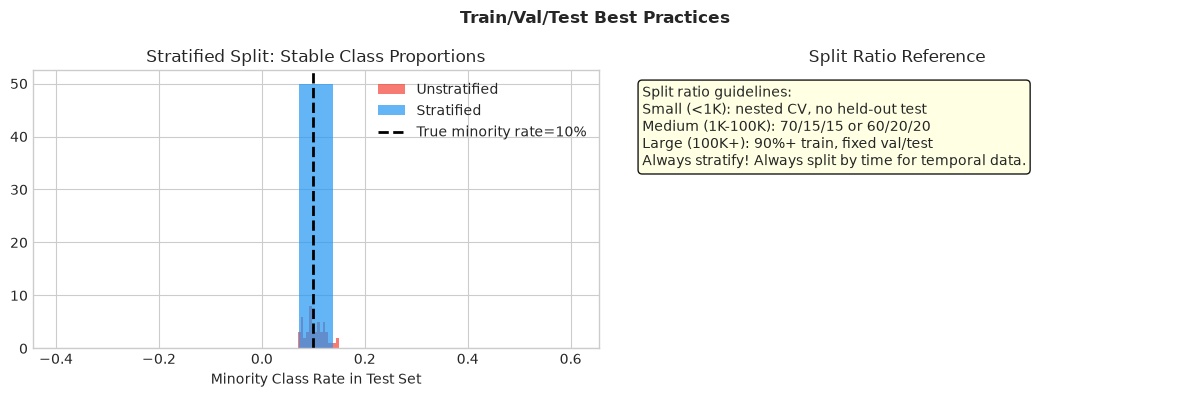

In [24]:
# -- Stratification importance ------------------------------------------------
np.random.seed(42)
X_strat, y_strat = make_classification(n_samples=1000, n_features=10,
                                        weights=[0.9, 0.1], random_state=42)

n_experiments = 50
unstratified_rates, stratified_rates = [], []

for seed in range(n_experiments):
    _, _, _, y_te1 = train_test_split(X_strat, y_strat, test_size=0.2, random_state=seed)
    _, _, _, y_te2 = train_test_split(X_strat, y_strat, test_size=0.2,
                                       stratify=y_strat, random_state=seed)
    unstratified_rates.append(y_te1.mean())
    stratified_rates.append(y_te2.mean())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(unstratified_rates, bins=15, color=COLORS[1], alpha=0.7, label='Unstratified')
ax1.hist(stratified_rates,   bins=15, color=COLORS[0], alpha=0.7, label='Stratified')
ax1.axvline(0.1, color='black', ls='--', lw=2, label='True minority rate=10%')
ax1.set_xlabel('Minority Class Rate in Test Set')
ax1.set_title('Stratified Split: Stable Class Proportions')
ax1.legend()

ax2.text(0.05, 0.95,
    "Split ratio guidelines:\n"
    "Small (<1K): nested CV, no held-out test\n"
    "Medium (1K-100K): 70/15/15 or 60/20/20\n"
    "Large (100K+): 90%+ train, fixed val/test\n"
    "Always stratify! Always split by time for temporal data.",
    transform=ax2.transAxes, fontsize=10, verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
ax2.axis('off');  ax2.set_title('Split Ratio Reference')

plt.suptitle('Train/Val/Test Best Practices', fontsize=12, fontweight='bold')
plt.tight_layout();  plt.show()

### INTERVIEW QUESTION
**"Why do we need a separate test set if we already use cross-validation?"**

**Senior DS Answer:**
> Cross-validation estimates generalization performance for a given model configuration. But if I use CV scores to compare 50 different models or hyperparameter combinations, the winning configuration is partly the one that got lucky on those folds — selection bias inflates the estimate.
>
> A held-out test set is completely untouched during all development decisions — model selection, hyperparameter tuning, feature engineering, threshold selection. It provides a final unbiased estimate of deployment performance. It should be evaluated exactly once.
>
> For small datasets, nested cross-validation replaces both: outer loops estimate generalization (5-10 folds), inner loops handle hyperparameter tuning (3-5 folds). Computationally expensive but statistically rigorous.
>
> The warning sign: a team that reports "we ran 50 experiments to get here" without a held-out test set has been peeking. If each experiment used the same test set, that test score is contaminated. Always ask: was this test set locked from day one?

---
## 15. Common Interview Questions: Senior-Level Model Answers

In [25]:
# -- Missing data strategies --------------------------------------------------
np.random.seed(42)
n = 500
df_missing = pd.DataFrame({
    'age':          np.random.randint(20, 70, n),
    'income':       np.random.normal(50000, 20000, n),
    'credit_score': np.random.randint(300, 850, n).astype(float),
    'loan_amount':  np.random.normal(20000, 5000, n),
    'target':       np.random.randint(0, 2, n),
})

# Introduce different missing patterns
df_missing.loc[np.random.choice(n, 50, replace=False), 'income'] = np.nan        # MCAR
df_missing.loc[df_missing['age'] > 60, 'credit_score'] = np.nan                  # MAR
df_missing.loc[df_missing['income'] < 30000, 'loan_amount'] = np.nan             # MNAR

print("Missing value counts:")
print(df_missing.isnull().sum())
print()

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

X_miss = df_missing[['age','income','credit_score','loan_amount']].values
y_miss = df_missing['target'].values

strategies = {
    'Mean imputation':   SimpleImputer(strategy='mean'),
    'Median imputation': SimpleImputer(strategy='median'),
    'KNN imputation':    KNNImputer(n_neighbors=5),
    'Iterative (MICE)':  IterativeImputer(random_state=42, max_iter=10),
}

print(f"{'Strategy':<25} {'CV AUC'}")
print("-" * 40)
for name, imputer in strategies.items():
    pipe = Pipeline([('imp', imputer),
                     ('scl', StandardScaler()),
                     ('clf', LogisticRegression(max_iter=1000))])
    score = cross_val_score(pipe, X_miss, y_miss, cv=5, scoring='roc_auc').mean()
    print(f"{name:<25} {score:.4f}")

print()
print("Also consider: adding a binary 'was_missing' indicator feature.")
print("For XGBoost/LightGBM: NaN is handled natively -- no imputation needed.")

Missing value counts:
age              0
income          50
credit_score    87
loan_amount     69
target           0
dtype: int64

Strategy                  CV AUC
----------------------------------------
Mean imputation           0.5083
Median imputation         0.5083


KNN imputation            0.5250
Iterative (MICE)          0.5095

Also consider: adding a binary 'was_missing' indicator feature.
For XGBoost/LightGBM: NaN is handled natively -- no imputation needed.


In [26]:
# -- Preventing overfitting: comprehensive checklist --------------------------
checklist = [
    "DIAGNOSIS:",
    "  [ ] Plot learning curves (train vs. val error vs. n_samples)",
    "  [ ] Check if gap closes as training data increases",
    "  [ ] Monitor train/val loss per epoch (neural nets)",
    "",
    "DATA SOLUTIONS:",
    "  [ ] Collect more training data",
    "  [ ] Data augmentation (images: flip/rotate/crop; text: paraphrase)",
    "  [ ] Remove or merge near-duplicate samples",
    "",
    "MODEL SOLUTIONS:",
    "  [ ] Reduce model complexity (fewer layers/depth/units/features)",
    "  [ ] L1 regularization (sparse weights, feature selection)",
    "  [ ] L2 regularization (weight decay, smooth solutions)",
    "  [ ] Dropout (randomly zero activations during training)",
    "  [ ] Early stopping (stop when val loss plateaus/increases)",
    "  [ ] Ensemble methods (averaging reduces variance)",
    "",
    "EVALUATION HYGIENE:",
    "  [ ] Use stratified CV, never report train accuracy as success metric",
    "  [ ] Hold out test set from the very start",
    "  [ ] Check for data leakage (pipeline everything)",
]

print("PREVENTING OVERFITTING: COMPLETE CHECKLIST")
print("=" * 60)
for line in checklist:
    print(line)

PREVENTING OVERFITTING: COMPLETE CHECKLIST
DIAGNOSIS:
  [ ] Plot learning curves (train vs. val error vs. n_samples)
  [ ] Check if gap closes as training data increases
  [ ] Monitor train/val loss per epoch (neural nets)

DATA SOLUTIONS:
  [ ] Collect more training data
  [ ] Data augmentation (images: flip/rotate/crop; text: paraphrase)
  [ ] Remove or merge near-duplicate samples

MODEL SOLUTIONS:
  [ ] Reduce model complexity (fewer layers/depth/units/features)
  [ ] L1 regularization (sparse weights, feature selection)
  [ ] L2 regularization (weight decay, smooth solutions)
  [ ] Dropout (randomly zero activations during training)
  [ ] Early stopping (stop when val loss plateaus/increases)
  [ ] Ensemble methods (averaging reduces variance)

EVALUATION HYGIENE:
  [ ] Use stratified CV, never report train accuracy as success metric
  [ ] Hold out test set from the very start
  [ ] Check for data leakage (pipeline everything)


In [27]:
# -- Key interview Q&A reference -----------------------------------------------
qa_pairs = [
    (
        "How would you handle missing data?",
        (
            "1. Understand WHY data is missing: MCAR (random), MAR (depends on observed data),\n"
            "   or MNAR (depends on missing value itself -- hardest case).\n"
            "2. Explore missingness patterns: df.isnull().corr() to find co-missingness.\n"
            "3. Choose strategy based on volume and type:\n"
            "   - <5% missing: mean/median imputation usually fine\n"
            "   - 5-30% missing: KNN or MICE (iterative) imputation\n"
            "   - >30% missing: add binary 'was_missing' indicator AND impute\n"
            "   - Tree models (XGBoost/LightGBM): handle NaN natively\n"
            "4. Never impute before train/test split -- fit imputer on train only.\n"
            "5. Consider dropping columns with very high missingness (>50%, low signal)."
        )
    ),
    (
        "How would you approach a new ML problem from scratch?",
        (
            "1. Understand business objective: What decision is made? Cost of FP vs FN?\n"
            "2. Explore data: shape, dtypes, missing values, class balance, distributions.\n"
            "3. Establish baselines: dummy classifier, simple logistic regression.\n"
            "4. Feature engineering: domain knowledge first, then automated.\n"
            "5. Model selection: benchmark 3-5 algorithms with CV.\n"
            "6. Hyperparameter tuning: Bayesian search with nested CV.\n"
            "7. Error analysis: examine specific misclassified examples.\n"
            "8. Final evaluation on held-out test set (exactly once).\n"
            "9. Production: latency, model size, monitoring, drift detection."
        )
    ),
    (
        "Explain gradient boosting at a high level",
        (
            "Start with a simple prediction (e.g., mean for regression).\n"
            "Compute residuals (errors of current ensemble).\n"
            "Train a shallow tree to predict those residuals.\n"
            "Add the tree to the ensemble with small learning rate (shrinkage).\n"
            "Repeat.\n\n"
            "It is 'gradient' boosting because residuals = negative gradient of loss function\n"
            "w.r.t. predictions -- gradient descent in function space.\n\n"
            "XGBoost adds: L1/L2 regularization, second-order Taylor approximation for\n"
            "more accurate updates, and column/row subsampling like Random Forest.\n"
            "This makes it the best general-purpose algorithm for tabular data."
        )
    ),
    (
        "What is precision vs recall in business terms?",
        (
            "Use fraud detection as the example:\n"
            "Precision = of transactions we flagged as fraud, what fraction were actually fraud?\n"
            "  (High precision = few false alarms = less customer friction)\n"
            "Recall = of all actual fraud transactions, what fraction did we catch?\n"
            "  (High recall = few missed frauds = less financial loss)\n\n"
            "The tradeoff: lowering the decision threshold raises recall but lowers precision.\n"
            "To choose: quantify the business cost of each error type, then optimize\n"
            "the threshold to minimize total expected cost. Never use accuracy alone.\n"
            "F1 is the harmonic mean -- useful when you need a single number\n"
            "and both precision and recall matter equally."
        )
    ),
]

for i, (q, a) in enumerate(qa_pairs):
    print("=" * 70)
    print(f"Q{i+1}: {q}")
    print("-" * 70)
    print("A:", a)
    print()

Q1: How would you handle missing data?
----------------------------------------------------------------------
A: 1. Understand WHY data is missing: MCAR (random), MAR (depends on observed data),
   or MNAR (depends on missing value itself -- hardest case).
2. Explore missingness patterns: df.isnull().corr() to find co-missingness.
3. Choose strategy based on volume and type:
   - <5% missing: mean/median imputation usually fine
   - 5-30% missing: KNN or MICE (iterative) imputation
   - >30% missing: add binary 'was_missing' indicator AND impute
   - Tree models (XGBoost/LightGBM): handle NaN natively
4. Never impute before train/test split -- fit imputer on train only.
5. Consider dropping columns with very high missingness (>50%, low signal).

Q2: How would you approach a new ML problem from scratch?
----------------------------------------------------------------------
A: 1. Understand business objective: What decision is made? Cost of FP vs FN?
2. Explore data: shape, dtypes, missi

---
## Quick Reference Summary

### The Golden Rules

1. **Split first, engineer second** — no test/val information should touch training
2. **Baseline before complexity** — always start with the simplest model
3. **Plot learning curves** — they diagnose every fundamental problem
4. **Choose metrics for the business** — accuracy is almost never the right metric
5. **Pipelines for everything** — prevents leakage, makes deployment easier
6. **Test set is sacred** — look at it exactly once, at the very end
7. **Cross-validate hyperparameter search** — nested CV for unbiased estimates
8. **Always stratify classification splits** — especially for imbalanced data
9. **Check for data leakage first** — #1 cause of production model failure
10. **No Free Lunch** — always benchmark multiple algorithms empirically

### Model Selection Quick Guide

| Situation | Start with |
|---|---|
| Tabular, binary/multiclass | XGBoost / LightGBM |
| Tabular, regression | Gradient Boosting or Random Forest |
| Need interpretability | Logistic / Linear Regression |
| High-dimensional (p >> n) | Lasso + Ridge CV |
| Images | Pretrained CNN (ResNet, EfficientNet) |
| Text | Pretrained transformers (BERT family) |
| Time series | Gradient Boosting + lag features |
| Very small dataset | Cross-validated linear model |

### Metric Selection Quick Guide

| Problem | Use |
|---|---|
| Balanced binary | AUC-ROC, F1 |
| Imbalanced binary | AUC-PR, F1 (minority class) |
| Fraud / rare events | Recall@K, AUC-PR |
| Regression, outliers matter | RMSE |
| Regression, robust | MAE |
| Relative error (no zero targets) | MAPE |
| Multi-class | Macro-F1, per-class F1 |

In [28]:
print("Notebook complete! All topics covered:")
topics = [
    "1.  Bias-Variance Tradeoff -- mathematical decomposition + visual demo",
    "2.  Overfitting vs Underfitting -- learning curves + solutions",
    "3.  Regularization -- L1 vs L2 vs ElasticNet with geometric intuition",
    "4.  Cross-Validation -- K-Fold, Stratified, TimeSeriesSplit, LOO",
    "5.  Data Leakage -- 5 types with live code demonstrations",
    "6.  Feature Selection -- Filter, Wrapper, Embedded methods",
    "7.  Class Imbalance -- class_weight, SMOTE, threshold tuning, AUC-PR",
    "8.  Evaluation Metrics -- complete classification + regression reference",
    "9.  Curse of Dimensionality -- distance concentration demo + KNN degradation",
    "10. No Free Lunch Theorem -- empirical demonstration across 4 datasets",
    "11. Gradient Descent -- Batch/SGD/Mini-batch/Momentum/Adam + LR schedules",
    "12. Hyperparameter Tuning -- Grid/Random/Bayesian with visual explanation",
    "13. Ensemble Methods -- Bagging/Boosting/Stacking with variance theory",
    "14. Train/Val/Test Splits -- contamination demo + nested CV",
    "15. Interview Q&A -- missing data, overfitting, gradient boosting, metrics",
]
for t in topics:
    print(f"  - {t}")
print()
print("15 core ML concepts | 20+ visualizations | 15+ interview Q&A pairs")

Notebook complete! All topics covered:
  - 1.  Bias-Variance Tradeoff -- mathematical decomposition + visual demo
  - 2.  Overfitting vs Underfitting -- learning curves + solutions
  - 3.  Regularization -- L1 vs L2 vs ElasticNet with geometric intuition
  - 4.  Cross-Validation -- K-Fold, Stratified, TimeSeriesSplit, LOO
  - 5.  Data Leakage -- 5 types with live code demonstrations
  - 6.  Feature Selection -- Filter, Wrapper, Embedded methods
  - 7.  Class Imbalance -- class_weight, SMOTE, threshold tuning, AUC-PR
  - 8.  Evaluation Metrics -- complete classification + regression reference
  - 9.  Curse of Dimensionality -- distance concentration demo + KNN degradation
  - 10. No Free Lunch Theorem -- empirical demonstration across 4 datasets
  - 11. Gradient Descent -- Batch/SGD/Mini-batch/Momentum/Adam + LR schedules
  - 12. Hyperparameter Tuning -- Grid/Random/Bayesian with visual explanation
  - 13. Ensemble Methods -- Bagging/Boosting/Stacking with variance theory
  - 14. Train/